# Data Generation
## Construction of Bosnia and Herzegovina Heritage Knowledge Base

Project Goal: Developing a structured dataset for a cultural chatbot focused on tourism, history, and gastronomy in Bosnia and Herzegovina.

This dataset consolidates over 200 verified locations, ranging from UNESCO World Heritage sites to "Hidden Gems." It is designed to provide a chatbot with high-precision geographic data and engaging cultural insights.
Key Features (2026 Version):

    Verified Coordinates: All latitude and longitude entries were manually fact-checked for 100% accuracy as of January 2026.
    Gastro-Cultural Integration: Indigenous food traditions (such as Ćevapi, Livanjski cheese, and Kiseljak flatbreads) are mapped to cultural landmarks.
    Regional Diversity: Data covers all major regions, including Sarajevo, Mostar, Banja Luka, Tuzla, Olovo, and Tomislavgrad.

Primary Data Sources:

    Federal Institute for Statistics (FZS) – Tourism and cumulative data (2025/2026).
    Commission to Preserve National Monuments – Official heritage listings.
    UNESCO World Heritage Center – Serial property and site data.
    Spomenik Database – Yugoslav-era monumental heritage.
  

In [130]:
  # Force install the specific versions
!pip install chromadb sentence-transformers opentelemetry-api==1.38.0 opentelemetry-sdk==1.38.0 opentelemetry-exporter-otlp-proto-http==1.38.0 -q

In [131]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
from io import StringIO
import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
import re
import seaborn as sns
import matplotlib.pyplot as plt
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:


columns = [
    "name", "location", "description", "category", "historical_period",
    "latitude", "longitude", "keywords", "tourism_season",
    "avg_visit_time", "popularity_level", "fun_fact", "source"
]

raw_data = """name,location,description,category,historical_period,latitude,longitude,keywords,tourism_season,avg_visit_time,popularity_level,fun_fact,source
"Stari Most","Mostar","A 16th-century Ottoman bridge crossing the Neretva river, a symbol of the city and a UNESCO World Heritage site.","Monument","Ottoman",43.3373,17.8150,"bridge, UNESCO, Ottoman, Neretva, architecture","Summer","1 hour",A,"Local divers jump from the bridge into the cold Neretva river as a traditional rite of passage.","https://en.wikipedia.org/wiki/Stari_Most"
"Baščaršija","Sarajevo","The historical and cultural center of Sarajevo, established in the 15th century as a market hub.It is the epicenter of Sarajevo's food culture.","Bazaar","Ottoman",43.8598,18.4313,"market, bazaar, crafts, cevapi, burek, coffee, tradition,sebilj, old town","All year","2-3 hours",A,"The name Baščaršija derives from the Turkish words 'baş' (head) and 'çarşı' (market).","https://en.wikipedia.org/wiki/Baščaršija"
"Kastel Fortress","Banja Luka","A historic fortress situated on the left bank of the Vrbas river, containing remains of Roman and Ottoman fortifications.","Fortress","Roman/Ottoman",44.7663,17.1889,"castle, fortification, river, history, cevapi","Spring-Summer","1-2 hours",A,"The fortress is one of the oldest buildings in Bosnia and Herzegovina with traces of Neolithic settlements.","https://en.wikipedia.org/wiki/Kastel_Fortress"
"Kamene kugle (Stone Spheres)","Zavidovići","Large, mysterious spherical stone formations found in the forest near Zavidovići.","nature","Unknown",44.4333,18.1500,"mystery, nature, archeology, stone spheres","Spring-Autumn","1 hour",C,"The largest sphere is estimated to weigh over 30 tons, making it one of the largest in Europe.","https://gozdici.com/en/stone-spheres/"
"Bosnian Pyramid of the Sun","Visoko","A hillsite claimed by some to be the largest man-made ancient pyramid in the world.","other heritage/leisure","Controversial",43.9800,18.1700,"pyramids, mystery, tunnels, Visoko","All year","3-4 hours",B,"The Ravne tunnels underneath the pyramids are claimed to have high concentrations of negative ions.","https://en.wikipedia.org/wiki/Bosnian_pyramid_claims"
"Obelisk near Olovo","Bakići, Olovo","A mysterious 14th-century stone monolith decorated with carvings of a boar, a snake, and a crescent.","National Monument","Medieval",44.1111,18.5778,"obelisk, monolith, medieval, mystery, carvings","Spring-Autumn","45 min",C,"The obelisk is a unique monument of the Bosnian Church, likely marking the tomb of a high-ranking noble.","https://lll.ba/obelisk-of-the-king-tvrtko/"
"Lukomir Village","Konjic/Bjelašnica","The highest and most isolated mountain village in Bosnia and Herzegovina, preserving traditional lifestyles.","Cultural Village","Medieval/Traditional",43.6139,18.1819,"mountains, hiking, traditional, village, high altitude","Summer","4-6 hours",C,"Lukomir is unique for its stone houses with cherry wood roof tiles.","https://en.wikipedia.org/wiki/Lukomir"
"AVNOJ Museum","Jajce","The building where the Second Session of the Anti-Fascist Council for the National Liberation of Yugoslavia was held in 1943.","Museum","Yugoslavia",44.3411,17.2703,"Yugoslavia, WWII, partisans, Tito, history","All year","1 hour",B,"Socialist Yugoslavia was officially born within these walls during the 1943 assembly.","https://en.wikipedia.org/wiki/Jajce"
"Tjentište (Sutjeska Memorial)","Tjentište","A massive brutalist monument commemorating the Battle of the Sutjeska during WWII.","Yugoslav Monument","Yugoslavia",43.3453,18.6861,"brutalism, WWII, memorial, hiking, Sutjeska","Spring-Autumn","1-2 hours",B,"The monument was designed by Miodrag Živković and is one of the most iconic Spomeniks in the Balkans.","https://en.wikipedia.org/wiki/Sutjeska_National_Park"
"Mehmed Paša Sokolović Bridge","Višegrad","A 16th-century Ottoman bridge designed by Mimar Sinan and featured in Ivo Andrić's famous novel.","Monument","Ottoman",43.7825,19.2878,"bridge, UNESCO, literature, Sinan, Drina","Summer","1 hour",A,"The bridge is the central 'character' in the Nobel-prize winning novel 'The Bridge on the Drina'.","https://en.wikipedia.org/wiki/Mehmed_Paša_Sokolović_Bridge"
"Blagaj Tekke","Blagaj","A Dervish monastery built into a 200m cliff next to the source of the Buna river.","Religious Site","Ottoman",43.2561,17.8931,"monastery, dervish, buna, river, nature","All year","1-2 hours",A,"The Buna river spring is one of the largest and most powerful karst springs in Europe.","https://en.wikipedia.org/wiki/Blagaj_Tekke"
"Radimlja Stećci Necropolis","Stolac","One of the most important medieval tombstones (stećci) sites in Bosnia, featuring intricate carvings.","National Monument","Medieval",43.0847,17.9222,"UNESCO, stećci, medieval, carvings, history","All year","1 hour",A,"The site features 133 tombstones, many with the iconic 'man with a raised hand' relief.","https://en.wikipedia.org/wiki/Radimlja"
"Vijećnica (City Hall)","Sarajevo","The most iconic building in Sarajevo, built in a pseudo-Moorish style, formerly the National Library.","Building","Austro-Hungarian",43.8592,18.4334,"library, architecture, history, Moorish","All year","1-2 hours",A,"The building was completely destroyed during the Siege of Sarajevo and reopened in 2014 after restoration.","https://en.wikipedia.org/wiki/Sarajevo_City_Hall"
"Počitelj","Čapljina","A historic fortified town on the banks of the Neretva, a living museum of Ottoman architecture.","Fortress Town","Medieval/Ottoman",43.1344,17.7314,"castle, Ottoman, photography, history, town","Spring-Summer","2-3 hours",A,"The town's Gavrankapetanović house was one of the first artist colonies in Southeast Europe.","https://en.wikipedia.org/wiki/Počitelj"
"Jajce Fortress","Jajce","The seat of the last Bosnian kings, overlooking the famous 22-meter high Pliva waterfall.","Fortress","Medieval",44.3422,17.2680,"castle, kings, waterfall, history, medieval","All year","2 hours",A,"Jajce is the only city in the world with a natural waterfall in its very center.","https://en.wikipedia.org/wiki/Jajce_Fortress"
"Bobovac","Vareš/Kakanj","The royal city and residence of Bosnian kings during the medieval period.","Fortress","Medieval",44.1167,18.2333,"royalty, medieval, ruins, history, hiking","Spring-Autumn","2 hours",C,"The Bosnian royal crown was kept here for safety due to its strategic, hard-to-reach location.","https://en.wikipedia.org/wiki/Bobovac"
"Tvrđava Srebrenik","Srebrenik","The best-preserved medieval fortress in Bosnia, perched on a steep rock cliff.","Fortress","Medieval",44.7033,18.5208,"castle, medieval, preservation, cliff","Spring-Summer","1.5 hours",B,"It was the historical seat of the Ban Stjepan II Kotromanić, who issued the famous charter there in 1333.","https://en.wikipedia.org/wiki/Srebrenik_Fortress"
"Kozara Monument","Kozara National Park","A revolutionary monument dedicated to the fallen fighters and civilians of the Battle of Kozara.","Yugoslav Monument","Yugoslavia",45.0125,16.9083,"memorial, WWII, brutalism, forest, history","Spring-Autumn","1-2 hours",B,"The monument is designed to symbolize the struggle between light and darkness.","https://en.wikipedia.org/wiki/Mrakovica"
"Mogorjelo","Čapljina","Remains of a 4th-century Roman villa rustica, one of the most important Roman sites in the country.","National Monument","Roman",43.1022,17.7011,"Roman, villa, archeology, Čapljina","Spring-Autumn","1 hour",B,"The site was originally a private farm and estate before being converted into a fortress.","https://en.wikipedia.org/wiki/Mogorjelo"
"Vjetrenica Cave","Ravno","The largest and most important cave in Bosnia and Herzegovina, known for its biodiversity.","Natural/Cultural","Ancient",42.8450,17.9850,"cave, nature, UNESCO, proteus, ancient","Spring-Autumn","1.5 hours",B,"It is the richest cave in the world in terms of subterranean biodiversity.","https://en.wikipedia.org/wiki/Vjetrenica"
"Kraljeva Sutjeska","Kakanj","The site of a Franciscan monastery and the ruins of a medieval royal court.","Religious Site","Medieval",44.1211,18.2019,"monastery, kings, medieval, history, church","All year","1.5 hours",C,"It was the residence of the last Bosnian Queen, Katarina, who is still mourned by local women wearing black headscarves.","https://en.wikipedia.org"
"Partisan Memorial Cemetery","Mostar","A monumental necropolis built to honor the Yugoslav partisans from Mostar.","Yugoslav Monument","Yugoslavia",43.3425,17.7981,"monument, Mostar, WWII, architecture, cemetery","All year","1 hour",B,"Designed by architect Bogdan Bogdanović, it resembles a stone city with flowered terraces.","https://en.wikipedia.org/wiki/Partisan_Memorial_Cemetery_in_Mostar"
"Daorson","Stolac","The ruins of the ancient capital of the Hellenized Illyrian tribe known as the Daorsi.","archaeological","Ancient",43.0967,17.9583,"Illyrian, ancient city, cyclopean walls, archeology","Spring-Autumn","1.5 hours",C,"The site features massive cyclopean walls built without mortar, similar to Mycenae.","https://en.wikipedia.org/wiki/Daorson"
"Tešanj Fortress","Tešanj","One of the largest and most significant fortresses in the country, with foundations from the 15th century.","Fortress","Medieval/Ottoman",44.6114,17.9861,"castle, medieval, tower, history","All year","1 hour",B,"The fortress has a 17-meter high clock tower that is still operational today.","https://en.wikipedia.org/wiki/Tešanj_Fortress"
"Stari Grad Ostrožac","Cazin","A unique castle featuring a mix of medieval, Ottoman, and Neo-Gothic architectural styles.","Fortress","Medieval/Austro-Hungarian",44.9125,15.9389,"castle, Cazin, architecture, sculpture park","Spring-Summer","1.5 hours",B,"It contains an outdoor sculpture park with works from international artists.","https://en.wikipedia.org/wiki/Ostrožac_Castle"
"Tvrđava Doboj","Doboj","A 13th-century fortress that served as a key defensive point in the Bosna river valley.","Fortress","Medieval",44.7336,18.0903,"castle, history, Doboj, defense","Spring-Autumn","1 hour",B,"The fortress was attacked and besieged over 50 times throughout history.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Museum of Contemporary Art (MSURS)","Banja Luka","A leading cultural institution located in the former Banja Luka railway station.","Museum","Modern",44.7731,17.1917,"art, museum, modern, Banja Luka","All year","1-2 hours",B,"The building itself is a protected national monument of architecture.","https://en.wikipedia.org/wiki/Museum_of_Modern_Art_of_Republika_Srpska"
"Konjic Old Bridge","Konjic","A beautiful 17th-century Ottoman bridge that connects the two banks of the Neretva.","Monument","Ottoman",43.6517,17.9614,"bridge, Konjic, Neretva, Ottoman","All year","30 min",B,"The bridge was destroyed by the retreating German army in 1945 and rebuilt in 2009.","https://www.tripadvisor.com/Attraction_Review-g1931691-d8310418-Reviews-Konjic_Bridge-Konjic_Herzegovina_Neretva_Canton_Federation_of_Bosnia_and_Herzego.html"
"Tito's Bunker (ARK D-0)","Konjic","A secret nuclear bunker built to protect Yugoslav leader Josip Broz Tito and 350 others.","Museum","Yugoslavia",43.6339,17.9897,"Cold War, bunker, secret, Tito, Yugoslavia","All year","2 hours",B,"It remained a state secret for decades, known only to a handful of high-ranking officials.","https://en.wikipedia.org/wiki/ARK_D-0"
"Fethija Mosque","Bihać","Originally built as a Catholic church in 1266, it was converted into a mosque in 1592.","Religious Site","Gothic/Ottoman",44.8114,15.8686,"mosque, church, Gothic, history, Bihać","All year","45 min",B,"It is one of the few examples of Gothic architecture that was preserved in Bosnia.","https://en.wikipedia.org/wiki/Fethija_Mosque_(Bihać)"
"Gradačac Fortress (Gradina)","Gradačac","The fortress of Husein Kapetan Gradaščević, known as the 'Dragon of Bosnia'.","Fortress","Ottoman",44.8797,18.4286,"castle, Dragon of Bosnia, history, tower","Spring-Autumn","1.5 hours",B,"The 18-meter high watchtower offers a panoramic view of the entire Posavina region.","https://en.wikipedia.org/wiki/Gradačac_Fortress"
"Travnik Fortress (Stari Grad)","Travnik","A medieval fortress that became a center of Ottoman administration for the Viziers.","Fortress","Medieval/Ottoman",44.2289,17.6719,"castle, Viziers, history, Travnik","All year","1 hour",A,"Travnik was the capital of the Ottoman governors (Viziers) of Bosnia for 150 years.","https://en.wikipedia.org/wiki/Travnik_Fortress"
"Birth House of Ivo Andrić","Travnik","A museum dedicated to the Nobel Prize-winning author of 'The Bridge on the Drina'.","Museum","Ottoman",44.2267,17.6667,"literature, museum, Nobel, Andrić","All year","1 hour",B,"The museum showcases the authentic interior of a 19th-century Bosnian house.","https://en.wikipedia.org/wiki/Ivo_Andrić"
"Trebinje Old Town (Kastel)","Trebinje","The historic walled center of Trebinje, located on the banks of the Trebišnjica river.","Old Town","Ottoman",42.7117,18.3456,"old town, river, Trebinje, architecture","Summer","2 hours",A,"Trebinje is often called the 'City of Sun and Plane Trees'.","https://en.wikipedia.org/wiki/Trebinje"
"Arslanagić Bridge","Trebinje","A 16th-century Ottoman bridge, moved stone by stone from its original location due to a dam.","Monument","Ottoman",42.7153,18.3564,"bridge, Trebinje, engineering, history","All year","30 min",B,"The bridge was relocated in 1972 to save it from the rising waters of a hydroelectric lake.","https://en.wikipedia.org/wiki/Arslanagić_Bridge"
"War Tunnel Museum (Tunel Spasa)","Sarajevo","The secret underground tunnel that kept Sarajevo supplied during the 1990s siege.","Museum","Modern",43.8200,18.3283,"war, siege, tunnel, history, Sarajevo","All year","1.5 hours",A,"The tunnel was the only way for food and medicine to enter the city during the 1,425-day siege.","https://en.wikipedia.org/wiki/Sarajevo_Tunnel"
"Latin Bridge","Sarajevo","An Ottoman bridge where the assassination of Archduke Franz Ferdinand took place in 1914.","Monument","Ottoman",43.8578,18.4289,"bridge, WWI, history, Sarajevo","All year","30 min",A,"This site is widely considered the location where World War I was triggered.","https://en.wikipedia.org/wiki/Latin_Bridge"
"Gazi Husrev-beg Mosque","Sarajevo","The largest historical mosque in Bosnia and Herzegovina and one of the most representative Ottoman structures in the Balkans.","Religious Site","Ottoman",43.8591,18.4290,"mosque, Ottoman, religion, architecture","All year","1 hour",A,"It was the first mosque in the world to receive electric lighting for its interior.","https://en.wikipedia.org/wiki/Gazi_Husrev-beg_Mosque"
"Srebrenica-Potočari Memorial","Srebrenica","A memorial and cemetery complex for the victims of the 1995 Srebrenica genocide.","Memorial","Modern",44.1581,19.3000,"memorial, genocide, history, war","All year","2-3 hours",A,"The memorial contains the names of over 8,000 victims of the genocide.","https://en.wikipedia.org/wiki/Srebrenica-Potočari_Memorial_Center"
"National Museum of Bosnia and Herzegovina","Sarajevo","The oldest modern cultural institution in the country, housing the famous Sarajevo Haggadah.","Museum","Austro-Hungarian",43.8550,18.4022,"museum, Haggadah, archeology, history","All year","2-3 hours",A,"The Sarajevo Haggadah is a 14th-century illuminated manuscript and one of the most valuable items in the museum.","https://en.wikipedia.org/wiki/National_Museum_of_Bosnia_and_Herzegovina"
"Prokoško Lake Katuni","Fojnica","High-altitude shepherd settlements around a glacial lake, showcasing traditional livestock farming.","Cultural Village","Traditional",43.9583,17.7514,"lake, village, hiking, tradition, mountains","Summer","4 hours",B,"The lake is home to the endemic Triton (Triturus alpestris reiseri), a rare amphibian.","https://en.wikipedia.org/wiki/Prokoško_Lake"
"Umoljani Village","Bjelašnica","An ancient mountain village with a dragon legend and unique stone architecture.","Cultural Village","Medieval",43.6672,18.2258,"hiking, legend, village, dragon, Bjelašnica","Spring-Autumn","3 hours",C,"A rock formation above the village is said to be the petrified tail of a legendary dragon.","https://en.wikipedia.org/wiki/Umoljani"
"Boljuni Stećci Necropolis","Stolac","A significant medieval necropolis with high artistic value in its tombstone carvings.","National Monument","Medieval",43.0306,17.8822,"stećci, medieval, history, Stolac","Spring-Autumn","1 hour",C,"The site has the highest number of inscriptions among all medieval necropolises in Bosnia.","https://en.wikipedia.org/wiki/Boljuni"
"St. Anthony of Padua Monastery","Banja Luka/Petrićevac","A significant Catholic monastery that was visited by Pope John Paul II in 2003.","Religious Site","Modern",44.7864,17.1714,"church, monastery, Catholic, Banja Luka","All year","1 hour",B,"The monastery was completely destroyed in 1995 and subsequently rebuilt as a modern architectural piece.","https://en.wikipedia.org/wiki/Petrićevac"
"Ferhadija Mosque","Banja Luka","A masterpiece of Ottoman architecture, destroyed in 1993 and painstakingly reconstructed stone by stone.","Religious Site","Ottoman",44.7675,17.1867,"mosque, architecture, restoration, Banja Luka","All year","1 hour",A,"The reconstruction used as many of the original stone fragments as possible, fished out of the river.","https://en.wikipedia.org/wiki/Ferhadija_Mosque_(Banja_Luka)"
"Atik Mosque","Bijeljina","One of the oldest mosques in Semberija, featuring a unique wooden minaret in its history.","Religious Site","Ottoman",44.7578,19.2197,"mosque, Bijeljina, Ottoman, history","All year","30 min",B,"The site also houses several old gravestones (nišani) of significant historical families.","https://en.wikipedia.org/wiki/Atik_Mosque"
"Livno Wild Horses Plateau","Livno","A vast natural plateau, famous for its wild horses and the production of high-quality Livanjski sir cheese.","Natural/Cultural","Modern",43.8500,17.0333,"wild horses, livanjski sir, cheese, food, nature","Spring-Autumn","3-4 hours",B,"The horses are descendants of domestic animals left behind when tractors replaced them in the 1970s. Also,Livanjski sir is a protected national cheese brand, originally made in the 19th century based on a French recipe.","https://en.wikipedia.org/wiki/Wild_horses_of_Livno"
"Tvrđava Maglaj","Maglaj","A medieval fortress built on a high rock above the Bosna river.","Fortress","Medieval",44.5458,18.1039,"castle, Maglaj, history, defense","Spring-Autumn","1 hour",B,"The fortress has a distinctive triangular layout adapted to the shape of the rock it sits on.","https://en.wikipedia.org/wiki/Maglaj_Fortress"
"Sarajevo Spite House (Inat kuća)","Sarajevo","A house moved stone by stone from one side of the river to the other to make room for the City Hall.","Building","Ottoman/Austro-Hungarian",43.8589,18.4328,"house, Sarajevo, legend, tradition","All year","1 hour",A,"The house remains a symbol of Bosnian defiance and stubbornness against authority.","https://en.wikipedia.org/wiki/Inat_kuća"
"Prusac (Ajvatovica)","Donji Vakuf","The site of the largest Muslim pilgrimage in Europe, celebrating a 500-year-old legend.","Religious Site","Ottoman",44.0933,17.3886,"pilgrimage, tradition, forest, religion","Summer","2 hours",B,"According to legend, Ajvaz Dedo prayed for 40 days for water until a massive rock split in half.","https://en.wikipedia.org/wiki/Ajvatovica"
"Buna Canals (Bunski Kanali)","Mostar","A stunning natural phenomenon where the turquoise Buna river flows into the Neretva through a narrow, dynamically sculpted limestone canyon shelf.","nature","Natural",43.2389,17.8361,"river, nature, Mostar, water, canyon, canals, junction, rapids","Summer","1 hour",B,"It is one of the most unique and beautiful natural river junctions in the Balkans, carving an island-like pathway through the rock layers.","https://en.wikipedia.org/wiki/Bunski_kanali"
"Jewish Cemetery","Sarajevo","The second largest Jewish burial ground in Europe, after the one in Prague.","National Monument","Medieval/Modern",43.8503,18.4069,"cemetery, Jewish, history, UNESCO nominee","All year","1 hour",B,"The cemetery features unique 'Sarajevo-style' tombstones that resemble medieval stećci.","https://en.wikipedia.org/wiki/Jewish_Cemetery,_Sarajevo"
"Kulen Vakuf Fortress (Ostrovica)","Kulen Vakuf","A massive medieval fortress overlooking the Una river valley in the Una National Park.","Fortress","Medieval",44.5611,16.0861,"castle, Una, nature, history","Summer","1.5 hours",C,"The fortress was a key strategic point between the Ottoman and Austro-Hungarian empires.","https://en.wikipedia.org/wiki/Ostrovica_Castle"
"Roman Bridge at Plandište","Ilidža, Sarajevo","A bridge built in the 16th century using authentic Roman stone blocks from nearby ruins.","Monument","Ottoman",43.8294,18.2708,"bridge, Roman, history, Ilidža","All year","30 min",B,"Despite its name, the bridge is Ottoman, but it gets the name from the Roman stones used in its construction.","https://en.wikipedia.org/wiki/Roman_Bridge_in_Ilidža"
"Husein-kapetan Gradaščević House","Gradačac","The family home of the leader of the Bosnian uprising against the Ottoman Empire.","National Monument","Ottoman",44.8814,18.4300,"history, Gradačac, architecture, hero","All year","1 hour",B,"The interior is preserved with authentic 19th-century furniture and personal belongings of the Captain.","https://en.wikipedia.org/wiki/Husein_Gradaščević"
"Tešanj Clock Tower","Tešanj","One of the few clock towers in Bosnia that still keeps accurate time for the local community.","Monument","Ottoman",44.6117,17.9867,"clock tower, Tešanj, history, landmark","All year","15 min",B,"The tower has survived several major fires and wars throughout its 300-year history.","https://en.wikipedia.org/wiki/Tešanj"
"Zavala Monastery","Ravno","A Serbian Orthodox monastery carved into a cliff, dating back to the 9th century according to legend.","Religious Site","Medieval",42.8483,17.9789,"monastery, Orthodox, cliff, history","All year","1 hour",C,"The monastery is located at the edge of Popovo Polje, one of the largest karst fields in the world.","https://en.wikipedia.org/wiki/Zavala_Monastery"
"Srebrenik Old Town","Srebrenik","The ruins of the old administrative center surrounding the famous Srebrenik fortress.","Historical Site","Medieval/Ottoman",44.7040,18.5215,"ruins, history, Srebrenik, town","Spring-Summer","1 hour",C,"Excavations have revealed several layers of habitation dating back to the prehistoric era.","https://en.wikipedia.org/wiki/Srebrenik_Fortress"
"Dumana Spring and Bridge","Livno","The breathtaking karst spring of the Bistrica river bursting out of a mountain cavern at the foot of Basajkovac hill, framed beautifully by an Ottoman-era stone bridge.","nature","Natural/Ottoman",43.8297,17.0097,"spring, river, nature, Livno, cave, bridge, Ottoman, karst","All year","45 min",C,"The roaring natural spring is named Duman, mimicking the historical Slavic word for the smoke-like mist created by the crashing water.","https://en.wikipedia.org/wiki/Livno"
"Musić Begovina","Stolac","A residential complex showcasing the high-style living of 19th-century Bosnian nobility.","National Monument","Ottoman",43.0833,17.9583,"architecture, house, Stolac, nobility","Spring-Summer","1 hour",C,"It is one of the best examples of the residential culture of the Ottoman era in Herzegovina.","https://en.wikipedia.org/wiki/Stolac"
"Vranduk Fortress","Zenica","A medieval table fortress located on a hill above the Bosna river, once a residence of kings.","Fortress","Medieval",44.2925,17.9042,"castle, medieval, kings, Zenica, defense","Spring-Summer","1 hour",B,"Vranduk is known as the 'Gate of Bosnia' because it controlled the main north-south valley.","https://en.wikipedia.org/wiki/Vranduk_Fortress"
"Old Town Stolac (Vidoški)","Stolac","A massive stone fortress with 13 towers, one of the largest in Bosnia and Herzegovina.","Fortress","Medieval/Ottoman",43.0831,17.9547,"castle, Stolac, fortification, panoramic","All year","2 hours",B,"The fortress sits on a site that has been fortified since the Illyrian and Roman times.","https://en.wikipedia.org/wiki/Stolac_Fortress"
"Sokolac Fortress","Bihać","A unique medieval tower perched on a steep hill overlooking the Una river valley.","Fortress","Medieval",44.7861,15.8953,"tower, Bihać, Una, medieval, photography","Spring-Autumn","1 hour",C,"The fortress was a key strategic point for the Frankopan family during the medieval era.","https://en.wikipedia.org/wiki/Sokolac_Fortress"
"Vrelo Bosne","Ilidža, Sarajevo","The source of the Bosna river, featuring a park with thermal springs and Austro-Hungarian bridges.","Natural/Cultural","Austro-Hungarian",43.8197,18.2694,"nature, park, river, Sarajevo, family","Spring-Summer","2-3 hours",A,"Visitors often arrive via a 3.5 km long alley of plane and chestnut trees in horse-drawn carriages.","https://en.wikipedia.org/wiki/Vrelo_Bosne"
"Herceg Stjepan Fortress","Blagaj","The ruins of a fortress once belonging to the Duke of St. Sava, overlooking the Blagaj Tekke.","Fortress","Medieval",43.2597,17.8914,"castle, Blagaj, history, panoramic, Duke Stjepan","Spring-Autumn","1.5 hours",B,"It was the seat of the Kosača noble family, who gave the region of Herzegovina its name.","https://en.wikipedia.org/wiki/Blagaj_Fortress"
"Bijela Tabija (White Fortress)","Sarajevo","A national monument overlooking the city, part of the old Vratnik walled city.","Fortress","Ottoman",43.8617,18.4433,"viewpoint, Sarajevo, fortification, sunset","All year","1 hour",A,"It offers one of the best panoramic views of Sarajevo's skyline and the Miljacka canyon.","https://en.wikipedia.org/wiki/Vratnik"
"Žuta Tabija (Yellow Bastion)","Sarajevo","An 18th-century cannon fortress that served as a key point in the city's defense.","Fortress","Ottoman",43.8606,18.4386,"viewpoint, Ramadan, history, Sarajevo","Spring-Summer","45 min",A,"During Ramadan, a cannon is fired from here to mark the time for Iftar (breaking the fast).","https://en.wikipedia.org/wiki/Yellow_Bastion"
"Atmejdan Park & Archeological Site","Sarajevo","An urban park containing the ruins of the 16th-century Bakr-Baba Mosque and a traditional madrasa.","Archeological Site","Ottoman",43.8572,18.4303,"park, ruins, Sarajevo, history","All year","30 min",B,"The name 'Atmejdan' literally means 'Horse Square' in Turkish, as it was a horse market.","https://en.wikipedia.org/wiki/Atmejdan"
"Museum of the Jews of BiH","Sarajevo","Located in the oldest synagogue in Sarajevo (Old Temple), showcasing 450 years of Jewish history.","Museum","Ottoman",43.8594,18.4281,"Jewish, synagogue, history, Sarajevo, museum","All year","1 hour",B,"The museum is housed in a building from 1581 that survived multiple fires and wars.","https://en.wikipedia.org/wiki/Museum_of_the_Jews_of_Bosnia_and_Herzegovina"
"Franciscan Monastery Museum Fojnica","Fojnica","Home to the Ahdnama, a 15th-century document granting religious freedom to Franciscans.","Museum","Medieval/Ottoman",43.9575,17.9022,"monastery, history, Ahdnama, Fojnica","All year","1.5 hours",B,"The Ahdnama is one of the oldest human rights documents in the Balkans, issued by Mehmed the Conqueror.","https://en.wikipedia.org/wiki/Fojnica_Franciscan_Monastery"
"Museum of Old Orthodox Church","Sarajevo","A 16th-century church containing a world-class collection of icons and liturgical objects.","Religious Site","Ottoman",43.8603,18.4308,"church, Orthodox, icons, Sarajevo, history","All year","1 hour",B,"The church is unique for its architectural plan, which is much wider than it is long.","https://en.wikipedia.org/wiki/Old_Orthodox_Church,_Sarajevo"
"Kraljeva Sutjeska Dusper House","Kakanj","The oldest surviving authentic Bosnian house in the Central Bosnia region.","National Monument","Ottoman",44.1211,18.2019,"architecture, traditional, house, heritage","Spring-Summer","45 min",C,"The house remains a perfect example of the 'musafirhana' or guest-house tradition.","http://kons.gov.ba/"
"Bijambare Caves and Park","Ilijaš","A protected landscape featuring five caves and high mountain meadows.","Natural/Cultural","Ancient",44.0911,18.5022,"caves, nature, park, hiking, Sarajevo","Spring-Autumn","2-3 hours",B,"The 'Main Cave' is known for its incredible natural acoustics, often called the Music Hall.","https://meetbosnia.com/bijambare-caves-protected-landscape/"
"Stara Pravoslavna Crkva","Mostar","A 19th-century Orthodox church overlooking the city, rebuilt after being destroyed in 1992.","Religious Site","Austro-Hungarian",43.3428,17.8189,"church, Orthodox, Mostar, view","All year","45 min",B,"The original church was a symbol of Mostar’s multicultural landscape before the war.","https://en.wikipedia.org/wiki/Mostar"
"Andrićgrad (Višegrad)","Višegrad","A cultural complex dedicated to Ivo Andrić, designed by filmmaker Emir Kusturica.","Cultural Village","Modern",43.7856,19.2922,"architecture, cinema, Andrić, Drina, tourism","All year","2 hours",A,"The 'city' is built from stone to resemble a medieval town that never actually existed.","https://en.wikipedia.org/wiki/Andrićgrad"
"Musić-begovina House","Stolac","An architectural complex representing the lifestyle of the Musić family in the 19th century.","National Monument","Ottoman",43.0842,17.9603,"nobility, Stolac, architecture, heritage","Spring-Summer","1 hour",C,"The house is a key example of the Mediterranean-influenced Ottoman residential style.","http://kons.gov.ba/"
"Stećci Necropolis Bijača","Ljubuški","A small but significant necropolis of medieval tombstones near the border with Croatia.","National Monument","Medieval",43.1256,17.5542,"stećci, Ljubuški, UNESCO, history","All year","45 min",C,"It is one of the 28 sites inscribed on the UNESCO World Heritage list of Stećci.","https://whc.unesco.org/en/list/1504"
"Fortress of Bočac","Mrkonjić Grad","Ruins of a medieval fortress perched on a cliff above the Vrbas river canyon.","Fortress","Medieval",44.5167,17.1667,"castle, Vrbas, canyon, hiking, ruins","Spring-Autumn","1 hour",C,"The fortress guarded the strategic crossing of the Vrbas river toward the south.","https://en.wikipedia.org/wiki/Bočac_Fortress"
"Museum of Woodcarving","Konjic","The Mulić’s Record museum, keeping the UNESCO-protected woodcarving tradition alive.","Museum","Modern",43.6525,17.9628,"woodcarving, UNESCO, Konjic, crafts","All year","1 hour",B,"Konjic woodcarving was officially inscribed on the UNESCO Intangible Cultural Heritage list in 2017.","https://ich.unesco.org/en/RL/konjic-woodcarving-01288"
"Pocitelj Sahat-kula (Clock Tower)","Počitelj","The stone clock tower that dominates the skyline of the historic town of Počitelj.","Monument","Ottoman",43.1347,17.7322,"tower, Počitelj, view, landmark","All year","30 min",A,"Unlike most Bosnian clock towers, this one does not have a clock face, as bells were used to tell time.","https://en.wikipedia.org/wiki/Počitelj"
"Hamam in Stolac","Stolac","The remains of a 16th-century public bathhouse, showcasing Ottoman hydraulic engineering.","National Monument","Ottoman",43.0839,17.9594,"bath, Stolac, architecture, engineering","Spring-Summer","30 min",C,"The Silahdar Husein-pasha hamam is one of the few preserved public baths in Herzegovina.","http://kons.gov.ba/"
"Despić House","Sarajevo","A house belonging to a wealthy Orthodox family, showcasing the birth of theater in the city.","Museum","Ottoman/Austro-Hungarian",43.8581,18.4272,"theater, history, Sarajevo, traditional","All year","1 hour",B,"The first theater performances in Sarajevo were held in the large hall of this house.","https://en.wikipedia.org/wiki/Despić_House"
"Hadži Ali-bey Mosque","Travnik","A unique mosque in Travnik with a sundial on its wall, still functional today.","Religious Site","Ottoman",44.2275,17.6681,"mosque, sundial, Travnik, history","All year","30 min",B,"It is the only mosque in Bosnia and Herzegovina that possesses a functional vertical sundial.","https://en.wikipedia.org/wiki/Travnik"
"Svrzo's House","Sarajevo","The most preserved example of a wealthy Ottoman-style merchant house in Sarajevo.","Museum","Ottoman",43.8614,18.4300,"house, museum, Sarajevo, lifestyle","All year","1 hour",A,"The house is divided into 'Selamluk' (public area) and 'Haremluk' (private family area).","https://en.wikipedia.org/wiki/Svrzo's_House"
"Muslibegović House","Mostar","A national monument and luxury hotel that preserves the layout of a 19th-century noble house.","Museum","Ottoman",43.3425,17.8139,"house, Mostar, heritage, luxury","All year","1 hour",B,"It is often cited as one of the most beautiful examples of Ottoman residential architecture in the Balkans.","https://en.wikipedia.org/wiki/Muslibegović_House"
"Trebinje Clock Tower","Trebinje","An 18th-century tower built by the Hadžismatović family in the center of the Old Town.","Monument","Ottoman",42.7119,18.3458,"clock tower, Trebinje, landmark, history","All year","15 min",B,"The tower was built using the famous local Herzegovina limestone.","https://en.wikipedia.org/wiki/Trebinje"
"Tvrđava Bužim","Bužim","A Renaissance-style fortress and the old town of the noble Frankopan family.","Fortress","Medieval/Ottoman",45.0522,16.0311,"castle, Bužim, history, border","Spring-Autumn","1 hour",C,"It is one of the few fortresses in Bosnia with a clear Renaissance polygonal bastioned layout.","https://en.wikipedia.org/wiki/Bužim"
"Ostrovica Castle","Kulen Vakuf","A massive fortification on a hill above Kulen Vakuf, offering a bird's eye view of the Una.","Fortress","Medieval",44.5622,16.0847,"castle, Una, Kulen Vakuf, viewpoint","Summer","2 hours",C,"The castle was a key stronghold for the Bosnian kingdom against Hungarian expansion.","https://en.wikipedia.org/wiki/Ostrovica_Castle"
"Kraljeva Sutjeska Library","Kakanj","A monastery library containing 31 incunabula (books printed before 1501).","Museum","Medieval",44.1206,18.2011,"books, history, library, monastery","All year","1 hour",B,"It is the most important collection of medieval and early modern books in the country.","https://en.wikipedia.org/wiki/Kraljeva_Sutjeska"
"Djevojacka Pecina (Maidens Cave)","Kladanj","A massive cave shelter featuring authentic prehistoric rock engravings alongside a famous local folklore legend about a brave young girl.","archaeological","Prehistoric/Medieval",44.2267,18.6833,"cave, legend, carvings, hiking, prehistoric, Kladanj, pilgrimage, art","Spring-Summer","1.5 hours",C,"Every August, thousands of people gather at this cave for a massive traditional prayer assembly rooted in century-old local customs.","https://www.atlasobscura.com/places/djevojacka-pecina-maidens-cave"
"Vraca Memorial Park","Sarajevo","A WWII memorial complex built on the site of an Austro-Hungarian fortress.","Yugoslav Monument","Yugoslavia",43.8447,18.4019,"WWII, brutalism, Sarajevo, memorial","All year","1 hour",B,"The names of over 11,000 victims of WWII are inscribed on the stone walls of the park.","https://en.wikipedia.org/wiki/Vraca_Memorial_Park"
"History Museum of BiH","Sarajevo","A museum focused on the 20th-century history of Bosnia, including a permanent exhibit on the Siege.","Museum","Yugoslavia/Modern",43.8547,18.4008,"war, history, Sarajevo, Yugoslavia","All year","1.5 hours",B,"The museum building is a masterpiece of Yugoslav modernist architecture, despite its battle-scarred exterior.","https://en.wikipedia.org/wiki/Historical_Museum_of_Bosnia_and_Herzegovina"
"Jewish Museum of Mostar","Mostar","A small community-run museum located in the reconstructed synagogue of Mostar.","Museum","Modern",43.3414,17.8117,"Jewish, Mostar, history, culture","All year","45 min",C,"The museum tells the story of Mostar's Sephardic Jewish community which was almost wiped out in WWII.","https://en.wikipedia.org/wiki/Mostar"
"Krusnica River Source","Bosanska Krupa","A stunning karst spring flowing directly out from under a massive mountain cliff, accessible primarily by traditional wooden boat or hiking through a dense forest.","nature","Natural/Cultural",44.8611,16.1722,"river, nature, boat, Krupa, hidden, spring, source, karst, forest, canyon","Summer","2 hours",C,"The water emerging from this deep underground cave source is so pure that it is bottled directly by local residents without treatment.","https://www.tripadvisor.com"
"Old Caravan Bridge Ruins of Visegrad","Visegrad","The historical archaeological remnants of an older crossing point and early caravan road structures situated near the grand Mehmed Pasa bridge.","archaeological","Ottoman",43.7831,19.2889,"ruins, history, Visegrad, Drina, bridge, Ottoman, caravan, tracks","Summer","30 min",C,"Local legends state that this older crossing infrastructure was a vital node for merchant trade networks long before Mimar Sinan built the main bridge.","https://en.wikipedia.org/wiki/Višegrad"
"Sinan-Begova Mosque","Čajniče","An 16th-century architectural gem known for its unique stone carvings and history.","Religious Site","Ottoman",43.5575,19.0719,"mosque, architecture, history, Čajniče","All year","45 min",C,"It was one of the most beautiful mosques in eastern Bosnia before its destruction and recent reconstruction.","http://kons.gov.ba/"
"Stećci Necropolis Mramorje","Perućac/Višegrad","A medieval cemetery located on the banks of the Drina river.","National Monument","Medieval",43.9667,19.4167,"UNESCO, stećci, river, history","All year","1 hour",C,"The site is part of the trans-border UNESCO protection of medieval tombstones.","https://whc.unesco.org/en/list/1504"
"Fortress of Ključ","Ključ","A large fortress on a cliff above the Sana river where the last Bosnian king was captured.","Fortress","Medieval",44.5333,16.7833,"castle, king, history, Sana","Spring-Autumn","1.5 hours",B,"It was here that King Stjepan Tomašević surrendered to the Ottoman Sultan Mehmed II in 1463.","https://en.wikipedia.org/wiki/Ključ_Fortress"
"Srebrenik Fortress","Srebrenik","One of the best-preserved medieval castles in BiH, perched on a massive rock.","Fortress","14th century",44.7031,18.5308,"fortress, medieval, castle","All Year","1.5 hours",B,"It was the historical seat of Ban Stjepan II Kotromanić, who issued a famous charter here in 1333.","https://en.wikipedia.org"
"Ostrožac Castle","Cazin","A unique castle featuring both a medieval fortress and a 19th-century Habsburg-style wing.","Fortress","16th-19th century",44.9042,15.9375,"castle, architecture, habsburg","All Year","2 hours",B,"It houses a unique outdoor sculpture garden within the walls.","https://en.wikipedia.org"
"Štrbački Buk","Bihać","The highest and most spectacular waterfall on the Una River.","Natural","Unknown",44.6564,16.0111,"waterfall, una, nature","Summer","3 hours",A,"Located within the Una National Park on the border with Croatia.","https://en.wikipedia.org"
"Martin Brod","Bihać","A complex of waterfalls and ancient watermills at the confluence of Una and Unac.","Natural","Unknown",44.4897,16.1425,"waterfall, river, mills","Spring-Summer","2 hours",B,"Famous for its traditional wool-washing 'natural washing machines'.","https://en.wikipedia.org"
"Prokoško Lake","Fojnica","A glacial lake surrounded by traditional wooden shepherd huts on Vranica mountain.","Natural/Village","Unknown",43.9583,17.7511,"lake, mountain, ethno","Summer","4 hours",B,"Home to the endemic Triton (Triturus alpestris reiseri) salamander.","https://en.wikipedia.org"
"Lukomir Village","Konjic","Bosnia's highest and most isolated mountain village with traditional stone houses.","Historic Site","Unknown",43.6333,18.1833,"ethno, village, mountain","Summer","5 hours",B,"Residents still wear traditional hand-knitted wool clothing.","https://en.wikipedia.org"
"Daorson","Stolac","Remains of a Hellenistic city built by the Illyrian tribe of Daorsi.","Archaeological","3rd century BC",43.0972,17.9472,"illyrian, ruins, ancient","All Year","1.5 hours",C,"The massive 'cyclopean' stone blocks resemble Mycenaean architecture.","https://en.wikipedia.org"
"Mogorjelo","Čapljina","Extremely well-preserved ruins of a Roman 'Villa Rustica'.","Archaeological","4th century",43.1022,17.6833,"roman, villa, ruins","All Year","1 hour",B,"The site was once a major agricultural production center for the Romans.","https://en.wikipedia.org"
"Vjetrenica Cave","Ravno","The largest and most important cave in BiH, famous for its biodiversity.","Natural","Unknown",42.8464,17.9844,"cave, nature, unesco","All Year","1.5 hours",A,"It is the richest cave in the world in terms of cave-dwelling animals and a UNESCO site since 2024.","https://en.wikipedia.org"
"Tešanj Fortress","Tešanj","One of the largest and most significant fortification complexes in Bosnia.","Fortress","15th century",44.6133,17.9861,"fortress, medieval, tower, history","All Year","1.5 hours",B,"The fortress has a 17-meter high clock tower that is still operational today.","https://en.wikipedia.org"
"Doboj Fortress","Doboj","A strategic medieval fortress guarding the Bosna river valley.","Fortress","13th century",44.7333,18.0833,"fortress, gradina, history","All Year","1 hour",B,"It has been destroyed and rebuilt over 20 times throughout history.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Gradačac Castle","Gradačac","Features the famous 'Dragon of Bosnia' tower overlooking the town.","Fortress","18th century",44.8789,18.4289,"castle, ottoman, history","All Year","1.5 hours",B,"Built by Husein-kapetan Gradaščević, a leader of the Bosnian autonomy movement.","https://en.wikipedia.org/wiki/Gradačac_Castle"
"Travnik Fortress","Travnik","Medieval fortress in the heart of the former capital of Bosnian Viziers.","Fortress","15th century",44.2289,17.6714,"viziers, fortress, history","All Year","1.5 hours",A,"The only fortress in the country with a clock tower built inside.","https://en.wikipedia.org/wiki/Travnik_Fortress"
"Šarena Džamija","Travnik","Known as the 'Painted Mosque' due to its unique floral exterior murals.","Religious","16th century",44.2264,17.6667,"mosque, art, ottoman","All Year","0.5 hours",A,"It is one of the very few mosques globally with a market (bezistan) inside its ground floor.","https://en.wikipedia.org/wiki/Šarena_Džamija"
"Panonska Jezera","Tuzla","Artificial salt lakes located in the city center, unique in Europe.","Natural/Rec","21st century",44.5383,18.6750,"salt lake, swimming, tuzla, cevapi, Limenka","Summer","4 hours",A,"The salt is pumped from natural underground deposits under the city.","https://en.wikipedia.org/wiki/Pannonian_Lakes"
"Mariastern Abbey","Banja Luka","Trappist monastery famous for its unique cheese production.","Religious","19th century",44.8058,17.2158,"monastery, trappist, cheese","All Year","1 hour",B,"It was once the only Trappist monastery in Southeastern Europe.","https://en.wikipedia.org/wiki/Mariastern_Abbey"
"Krupa na Vrbasu","Banja Luka","Natural area with cascades and ancient watermills near a medieval monastery.","Natural","Unknown",44.6186,17.1389,"waterfall, mills, nature","All Year","2 hours",B,"Famous for its wood-shingle mills that are still operational.","https://en.wikipedia.org/wiki/Krupa_na_Vrbasu"
"Zelengora Lakes","Sutjeska NP","A series of 8 glacial lakes known as 'Mountain Eyes'.","Natural","Unknown",43.3458,18.5750,"lake, hiking, nature","Summer","6 hours",C,"Considered by many to be the most beautiful mountain in the Dinarides.","https://en.wikipedia.org/wiki/Zelengora"
"Perućica Forest","Sutjeska NP","One of the two last remaining primeval forests in Europe.","Natural","Prehistoric",43.3500,18.7000,"forest, nature, unesco","Summer","5 hours",B,"Includes the 75-meter high Skakavac waterfall, hidden deep in the forest.","https://en.wikipedia.org/wiki/Perućica"
"Tvrdoš Monastery","Trebinje","15th-century Orthodox monastery famous for its wine cellars.","Religious","15th century",42.7164,18.2867,"monastery, wine, orthodox","All Year","1 hour",A,"Built on the foundations of a 4th-century Roman church.","https://en.wikipedia.org/wiki/Tvrdoš_Monastery"
"Arslanagić Bridge","Trebinje","An elegant Ottoman bridge relocated stone-by-stone to its current location.","Bridge","16th century",42.7156,18.3556,"bridge, ottoman, trebinje","All Year","0.5 hours",B,"It was moved in the 1970s to save it from a hydroelectric dam project.","https://en.wikipedia.org/wiki/Arslanagić_Bridge"
"Žitomislić Monastery","Mostar","One of the most important Orthodox monasteries in Herzegovina.","Religious","16th century",43.2039,17.7817,"monastery, history, orthodox","All Year","1 hour",B,"Known for its museum of icons and manuscripts.","https://en.wikipedia.org/wiki/Žitomislić_Monastery"
"Bliha Falls","Sanski Most","A stunning 56-meter waterfall where the river falls over a vertical cliff.","Natural","Unknown",44.7867,16.5414,"waterfall, nature, sanski most","All Year","1 hour",B,"The waterfall is also known as 'Blihin Skakavac'.","https://en.wikipedia.org/wiki/Bliha_Falls"
"Hutovo Blato","Čapljina","A nature reserve and bird sanctuary, one of the largest in the Balkans.","Natural","Unknown",43.0500,17.7833,"birds, marsh, safari","Spring/Summer","3 hours",B,"It is a major wintering ground for over 240 species of migratory birds.","https://en.wikipedia.org/wiki/Hutovo_Blato"
"Japodski Otoci","Bihać","A unique eco-tourism site consisting of river islands shaped like a heart.","Natural/Rec","Unknown",44.7500,15.9167,"una, islands, eco","Summer","3 hours",B,"Designed to resemble an ancient Japodian settlement.","https://en.wikipedia.org/wiki/Una_National_Park"
"Kozara National Park","Prijedor","Site of a major WWII battle and home to a monumental memorial sculpture.","Natural/Mem","20th century",45.0139,16.8917,"wwii, memorial, mountain","All Year","3 hours",A,"Known as the 'Green Heart of Krajina'.","https://en.wikipedia.org/wiki/Kozara_National_Park"
"Hajdučka Vrata","Čvrsnica","A natural stone arch formed by wind erosion on the Čvrsnica mountain.","Natural","Unknown",43.6139,17.6250,"hiking, nature, arch","Summer","7 hours",C,"One of the most photographed natural landmarks for hikers in BiH.","https://en.wikipedia.org/wiki/Čvrsnica"
"Maglaj Fortress","Maglaj","Dominates the old town and has a unique five-sided tower.","Fortress","15th century",44.5450,18.1033,"fortress, ottoman, history","All Year","1 hour",C,"The fortress has a rare combination of medieval and ottoman defensive styles.","https://en.wikipedia.org/wiki/Maglaj_Fortress"
"Ravne Tunnels","Visoko","Underground tunnel labyrinth located near the Bosnian Pyramids.","Archaeological","Unknown",43.9967,18.1692,"pyramid, tunnels, mystery","All Year","1.5 hours",A,"Visitors claim the air in the tunnels has healing properties due to high ions.","https://en.wikipedia.org/wiki/Visoko_pyramids"
"Old Town Počitelj","Počitelj","An open-air museum and historic village within a walled fortress.","Historic Site","14th century",43.1333,17.7333,"ottoman, unesco, art","All Year","2 hours",A,"Home to the longest-operating art colony in Southeast Europe.","https://en.wikipedia.org/wiki/Počitelj"
"Tito's Bunker","Konjic","A massive top-secret underground atomic shelter built for the Yugoslav elite.","Modern History","20th century",43.6358,17.9942,"cold war, bunker, konjic","All Year","2 hours",A,"It was one of the most expensive structures built in the former Yugoslavia.","https://en.wikipedia.org/wiki/Armijska_Ratna_Komanda_D-0"
"Umoljani Village","Bjelašnica","Ancient mountain village famous for the legend of the 'Cold Snake'.","Ethno Village","Unknown",43.6667,18.2333,"ethno, mountain, myth","Summer","3 hours",B,"Features unique tombstones and a mosque with a wooden minaret.","https://en.wikipedia.org/wiki/Umoljani"
"Bijambare Caves","Ilijaš","A protected landscape with five caves and beautiful pine forests.","Natural","Unknown",44.0833,18.5000,"cave, park, forest","All Year","2.5 hours",B,"The 'Middle Cave' is famous for its acoustics and is called the Music Hall.","https://en.wikipedia.org/wiki/Bijambare"
"Bobovac Fortress","Vareš","The seat of the Bosnian kings and the site of the royal burial chapel.","Fortress","14th century",44.1167,18.2500,"kings, royalty, history","All Year","2 hours",B,"It was the last place where the Bosnian royal crown was kept.","https://en.wikipedia.org/wiki/Bobovac"
"Art Gallery of BiH","Sarajevo","The oldest and most important art institution in the country, featuring over 6,000 works of art.","Museum","Austro-Hungarian",43.8586,18.4231,"art, gallery, culture, Sarajevo, paintings","All year","2 hours",B,"The gallery was founded just after WWII to preserve the Bosnian artistic heritage.","https://en.wikipedia.org/wiki/Art_Gallery_of_Bosnia_and_Herzegovina"
"Museum of Sarajevo 1878–1918","Sarajevo","A museum located at the corner where the assassination of Archduke Franz Ferdinand took place.","Museum","Austro-Hungarian",43.8578,18.4289,"assassination, WWI, history, Sarajevo, Hapsburg","All year","1 hour",A,"The museum building was originally a shop before becoming one of the most famous street corners in history.","https://en.wikipedia.org/wiki/Museum_of_Sarajevo_1878–1918"
"Musić-Begovina","Stolac","A residential complex that is a masterpiece of 19th-century Mediterranean-Ottoman architecture.","National Monument","Ottoman",43.0833,17.9583,"Stolac, architecture, house, heritage","Spring-Summer","1 hour",C,"The complex includes a private garden and a distinct layout designed for summer cooling.","http://kons.gov.ba/"
"Maculje Stećci Necropolis","Novi Travnik","A high-altitude necropolis featuring unique 'apple-shaped' tombstones.","National Monument","Medieval",44.1139,17.6144,"UNESCO, stećci, mountains, history","Spring-Autumn","1 hour",C,"It is situated at 1,200 meters above sea level, offering views of the Central Bosnian mountains.","https://whc.unesco.org/en/list/1504"
"Fortress of Soko Grad","Gračanica/Soko","The ruins of a medieval fortress that served as a strategic watchpoint in North Bosnia.","Fortress","Medieval",44.7500,18.3000,"castle, ruins, defense, Gračanica","Spring-Summer","1 hour",C,"The fortress was built on a steep limestone ridge that made it nearly impregnable.","https://en.wikipedia.org/wiki/Gračanica"
"Ljubuški Fortress (Herceg Stjepan)","Ljubuški","A medieval fortress built on the Butorovica hill, later expanded by the Ottomans.","Fortress","Medieval/Ottoman",43.2031,17.4439,"castle, Ljubuški, fortification, view","All year","1 hour",B,"It is the only fortress in the coastal hinterland that was never fully conquered by the Venetians.","https://en.wikipedia.org/wiki/Ljubuški_Fortress"
"St. Mary’s Church & St. Luke’s Tower","Jajce","The coronation site of the last Bosnian king, later converted into a mosque and then ruined.","Religious Site","Medieval",44.3417,17.2692,"church, tower, coronation, history, Jajce","All year","45 min",B,"St. Luke’s Tower is the only preserved medieval belfry in the mainland Balkans.","https://en.wikipedia.org/wiki/Jajce"
"Church of the Holy Virgin","Čajniče","Home to the 'Čajniče Krasnica', the only miracle-working icon of the Virgin Mary in BiH.","Religious Site","Medieval/Ottoman",43.5572,19.0722,"Orthodox, icon, pilgrimage, history","All year","1 hour",B,"The icon is believed by locals to have been painted by the Apostle Luke.","https://en.wikipedia.org/wiki/Čajniče"
"Old Bridge in Mostar (Museum)","Mostar","A museum located inside the Tara and Halebija towers of the Stari Most bridge.","Museum","Modern",43.3375,17.8153,"Mostar, bridge, history, museum, UNESCO","All year","1 hour",A,"The museum includes an underground section where you can see the original 16th-century foundations.","https://www.tripadvisor.com/Attraction_Review-g295387-d1158434"
"Necropolis Mramorje in Musići","Olovo","A medieval cemetery with 43 tombstones, including rare gable-shaped stećci.","National Monument","Medieval",44.1278,18.5833,"stećci, UNESCO, Olovo, history","Spring-Autumn","45 min",C,"The site is surrounded by dense coniferous forests, typical of the Olovo region.","https://whc.unesco.org/en/list/1504"
"Fortress of Glamoč","Glamoč","A hilltop fortress featuring a unique circular 'Tabija' tower from the Ottoman period.","Fortress","Medieval/Ottoman",44.0472,16.8494,"castle, Glamoč, fortification, remote","Spring-Autumn","1 hour",C,"The fortress was a vital link in the 'Kliški Sandžak' defense line against the Venetians.","https://en.wikipedia.org/wiki/Glamoč"
"Husein-Kapetan Gradaščević Mosque","Gradačac","A large mosque built by the 'Dragon of Bosnia' near his family castle.","Religious Site","Ottoman",44.8803,18.4289,"mosque, Gradačac, history, architecture","All year","45 min",B,"The mosque's minaret is 40 meters high, making it a landmark of the Posavina region.","https://en.wikipedia.org/wiki/Gradačac"
"Olympic Museum","Sarajevo","A museum dedicated to the 14th Winter Olympic Games held in Sarajevo in 1984.","Museum","Modern",43.8592,18.4128,"Olympics, 1984, history, Sarajevo, museum","All year","1.5 hours",B,"The museum is housed in the Mandić villa, which was the first building destroyed during the 1992 siege.","https://en.wikipedia.org/wiki/Sarajevo_Olympic_Museum"
"Tvrđava Soko (Šipovo)","Šipovo","The remains of a medieval fortress located above the canyon of the river Sokočnica.","Fortress","Medieval",44.2833,17.0833,"castle, canyon, nature, Šipovo","Spring-Summer","1 hour",C,"The fortress is mentioned in historical documents as early as 1363.","https://en.wikipedia.org/wiki/Šipovo"
"Brusa Bezistan","Sarajevo","A 16th-century covered market built by Rustem-pasha, now housing part of the Sarajevo Museum.","Museum","Ottoman",43.8594,18.4300,"bazaar, market, history, Sarajevo, museum","All year","1 hour",A,"The building features six large and two small domes, a classic example of Ottoman trade architecture.","https://en.wikipedia.org/wiki/Brusa_Bezistan"
"Franciscan Monastery Kraljeva Sutjeska","Kakanj","A spiritual and cultural center for centuries, holding the archives of the Bosnian state.","Religious Site","Medieval",44.1206,18.2014,"monastery, history, archive, Catholic","All year","2 hours",B,"It houses the oldest painting in Bosnia, 'The Adoration of the Magi' from the 15th century.","https://en.wikipedia.org/wiki/Kraljeva_Sutjeska"
"Hadzi-Beg Fortress (Hutovo)","Hutovo/Neum","The only major historical fortress complex in the Neum hinterland, featuring stone towers and defensive ramparts once ruled by the fiercely independent captain Hadzi-Beg.","fortress","Ottoman",42.9478,17.7889,"castle, fortress, Neum, history, coastal, Ottoman, towers, ramparts, Hutovo","Spring-Summer","1 hour",C,"Hadzi-Beg was legendary for his semi-autonomous rule and his stubborn, frequent military conflicts with the Ottoman Vizier of Travnik.","https://en.wikipedia.org/wiki/Hutovo_fortress"
"Mehmed-Beg Kapetanović Tower","Ljubuški","A 19th-century residential tower built for the local captain and nobleman.","National Monument","Ottoman",43.1972,17.4472,"tower, noble, history, Ljubuški","Spring-Autumn","30 min",C,"The tower is a rare surviving example of a fortified residential 'kula' in the Herzegovina region.","http://kons.gov.ba/"
"Stećci Necropolis Kalufi","Nevesinje","The largest necropolis of stećci in Bosnia and Herzegovina, with 452 tombstones.","National Monument","Medieval",43.2500,18.1167,"stećci, Nevesinje, history, heritage","Spring-Autumn","1.5 hours",C,"Despite its size, this necropolis is rarely visited due to its remote mountain location.","https://whc.unesco.org/en/list/1504"
"Fortress of Prozor","Prozor-Rama","The ruins of a medieval fortress that guarded the passage between Central Bosnia and Herzegovina.","Fortress","Medieval",43.8208,17.6083,"castle, Prozor, ruins, history","Spring-Autumn","1 hour",C,"It was a strategic stronghold for the Kotromanić royal dynasty.","https://en.wikipedia.org/wiki/Prozor-Rama"
"Gazi Husrev-beg Library","Sarajevo","One of the oldest libraries in Europe, housing over 10,000 Islamic manuscripts.","Museum","Ottoman",43.8594,18.4297,"books, library, manuscripts, Sarajevo, history","All year","1 hour",B,"The library's collection was saved during the 1990s war by people hiding books in private homes.","https://en.wikipedia.org/wiki/Gazi_Husrev-beg_Library"
"Museum of the Second Session of AVNOJ","Jajce","The museum dedicated to the 1943 meeting where the federal state of Yugoslavia was designed.","Museum","Yugoslavia",44.3397,17.2711,"Yugoslavia, WWII, partisans, Jajce, history","All year","1 hour",B,"The museum preserves the original chairs and tables used by the delegates during the 1943 meeting.","https://en.wikipedia.org/wiki/Jajce"
"Tvrđava Novi Grad","Novi Grad","A 19th-century fortress on the banks of the Una and Sana rivers.","Fortress","Austro-Hungarian",45.0458,16.3750,"castle, Una, border, defense","All year","1 hour",B,"The fortress marks the historic border point between the Ottoman and Austro-Hungarian empires.","https://en.wikipedia.org/wiki/Novi_Grad,_Bosnia_and_Herzegovina"
"Franciscan Monastery Plehan","Derventa","A modern monastery built on the ruins of one destroyed in 1992, featuring contemporary art.","Religious Site","Modern",44.9167,17.9833,"monastery, art, modern, Catholic, history","All year","1 hour",C,"The monastery is known as the 'Religious Art Center' due to its vast collection of modern sculptures.","https://en.wikipedia.org/wiki/Plehan"
"Stara Čaršija u Gradačcu","Gradačac","The old commercial heart of Gradačac, centered around the Captain’s castle.","Bazaar","Ottoman",44.8817,18.4303,"market, Gradačac, history, bazaar","All year","1 hour",B,"The area still maintains the traditional 'čardak' style houses typical of northern Bosnia.","https://en.wikipedia.org/wiki/Gradačac"
"Roman Mosaic at Skelani","Srebrenica/Skelani","Extensive archaeological excavations of a major 4th-century Roman administrative center, showcasing some of the best-preserved floor mosaics in the region.","archaeological","Roman",43.9789,19.5167,"Roman, mosaic, archaeology, Srebrenica, Skelani, ancient, palace, ruins, Drina","Spring-Summer","1.5 hours",C,"Discovered recently in 2008, the complex includes remains of a Roman villa rustica and a imperial basilica boasting magnificent geometric colored artwork floors.","https://en.wikipedia.org/wiki/Skelani"
"Fortress of Orašac","Bihać/Orašac","A small but strategically vital Ottoman-era fortress overlooking the Una river.","Fortress","Ottoman",44.6292,16.0714,"castle, Una, Bihać, history","Spring-Autumn","45 min",C,"The fortress was part of the westernmost defensive ring of the Ottoman Empire.","https://en.wikipedia.org/wiki/Orašac,_Bihać"
"Svrzo's House Annex","Sarajevo","A separate wing of the famous Svrzo's house that served as the business quarters.","Museum","Ottoman",43.8617,18.4303,"house, business, history, Sarajevo","All year","30 min",B,"It demonstrates how 18th-century Bosnian merchants separated their family life from their commercial deals.","https://en.wikipedia.org/wiki/Svrzo's_House"
"Kuršumlija Madrasa","Sarajevo","A 16th-century high school for Islamic studies, known for its lead-covered domes.","National Monument","Ottoman",43.8592,18.4294,"school, education, architecture, Sarajevo","All year","30 min",B,"The name 'Kuršumlija' comes from the Turkish word for lead (kurşun), which covers the roof.","https://en.wikipedia.org/wiki/Gazi_Husrev-beg_Madrasa"
"Old Town of Visoko (Čajangrad)","Visoko","The ruins of a medieval fortress that guarded the central Bosnian trade routes.","Fortress","Medieval",43.9917,18.1750,"castle, ruins, Visoko, kings","Spring-Autumn","1.5 hours",C,"It was one of the many fortifications that formed the defense system for the royal court in Moštre.","https://en.wikipedia.org/wiki/Visoko"
"Bridge on the Žepa River","Rogatica","An Ottoman stone bridge, famously described in a short story by Ivo Andrić.","Monument","Ottoman",43.9511,19.1306,"bridge, literature, Drina, history","Summer","45 min",C,"The bridge was relocated in 1966 due to the construction of a hydroelectric power plant on the Drina.","https://en.wikipedia.org/wiki/Bridge_on_Žepa"
"Fortress of Krupa na Uni","Bosanska Krupa","A fortress situated on a small island in the Una river, integrated into the town.","Fortress","Medieval/Ottoman",44.8828,16.1517,"castle, river, Una, Bihać","All year","1 hour",B,"The fortress walls are so close to the water that they appear to rise directly out of the Una river.","https://en.wikipedia.org/wiki/Bosanska_Krupa"
"Sarajevo Clock Tower (Sahat-kula)","Sarajevo","The only public clock in the world that keeps lunar time (a la turca).","Monument","Ottoman",43.8592,18.4292,"clock tower, time, Sarajevo, landmark","All year","15 min",A,"The clock is set to strike 12:00 exactly at sunset to mark the time for evening prayers.","https://en.wikipedia.org/wiki/Sarajevo_Clock_Tower"
"Vareš Old Church of St. Michael","Vareš","The oldest Catholic church in Bosnia that was never converted or destroyed throughout Ottoman rule.","Religious Site","Ottoman",44.1644,18.3289,"church, history, Vareš, Catholic","All year","45 min",C,"The church is built of stone and wood and looks more like a traditional house to avoid attracting attention.","http://kons.gov.ba/"
"Stećci Necropolis Grebnice","Stolac/Bunčići","A necropolis located on a ridge with tombstones featuring unique cross and shield reliefs.","National Monument","Medieval",43.0583,18.0667,"stećci, UNESCO, Stolac, history","Spring-Autumn","1 hour",C,"It is part of the high-concentration area of stećci around Stolac, a hotspot for medieval archeology.","https://whc.unesco.org/en/list/1504"
"Fortress of Livno (Bistrica)","Livno","A fortification complex above the source of the river Bistrica, known as 'Vejs Kula'.","Fortress","Ottoman",43.8306,17.0117,"castle, Livno, view, history","Spring-Summer","1 hour",C,"The fortress once housed a massive grain storage to feed the border garrisons.","https://en.wikipedia.org/wiki/Livno"
"Museum of the Franciscan Monastery Gorica","Livno","A museum housing an ethnological collection and works by the painter Gabriel Jurkić.","Museum","Austro-Hungarian",43.8250,17.0250,"monastery, art, history, Livno","All year","1.5 hours",B,"It contains one of the best-preserved collections of traditional folk costumes from western Bosnia.","https://en.wikipedia.org/wiki/Gorica_Monastery"
"Old Mosque in Pliva","Jajce/Pliva","A rare wooden mosque built in a style unique to the forest regions of Bosnia.","Religious Site","Ottoman",44.3456,17.2111,"mosque, wood, Jajce, tradition","All year","30 min",C,"The mosque's minaret is made entirely of wood, using no metal nails in its original construction.","http://kons.gov.ba/"
"Fortress of Gradina (Cazin)","Cazin","A medieval fortress that was once the seat of the Bishops of Knin.","Fortress","Medieval",44.9667,15.9333,"castle, Cazin, history, defense","Spring-Autumn","1 hour",C,"The fortress was a key northern defense point before the Ottoman conquest of Bihać.","https://en.wikipedia.org/wiki/Cazin"
"Museum of the Battle for the Wounded","Jablanica","A museum dedicated to the Battle of the Neretva, featuring a collapsed bridge in the river.","Museum/Yugoslav Monument","Yugoslavia",43.6603,17.7619,"WWII, Tito, partisans, Neretva, bridge","All year","2 hours",A,"The collapsed bridge in the river was actually blown up twice—once during the war and once for a 1969 film.","https://en.wikipedia.org/wiki/Jablanica"
"Gornji Grad Fortress","Gračanica","A medieval fortress guarding the Spreča valley, later expanded by the Ottomans.","Fortress","Medieval/Ottoman",44.7042,18.3125,"castle, Gračanica, defense, history","Spring-Autumn","1 hour",C,"The fortress offers a view of the entire industrial basin of northern Bosnia.","https://en.wikipedia.org/wiki/Gračanica"
"Gradina in Gornji Pale","Pale","The remains of a medieval fortified residence of the Pavlović noble family.","National Monument","Medieval",43.8111,18.5667,"noble, ruins, Pale, Pavlovići","Spring-Summer","1 hour",C,"It was one of the key defensive points protecting the road to the royal city of Bobovac.","http://kons.gov.ba/"
"Monastery of St. Nicholas","Ozren","A 14th-century Serbian Orthodox monastery known for its unique fresco paintings.","Religious Site","Medieval",44.5942,18.3242,"monastery, Orthodox, frescoes, Ozren","All year","1.5 hours",B,"The monastery was a major center for copying manuscripts during the Ottoman period.","https://en.wikipedia.org/wiki/Ozren_Monastery"
"Old Mosque in Šerići","Živinice","A rare example of a wooden mosque with a porch and a wooden minaret, preserved in its original form.","Religious Site","Ottoman",44.4789,18.5233,"mosque, wood, architecture, Živinice","All year","30 min",C,"It is one of the few wooden mosques in the Tuzla region that survived the wars of the 20th century.","http://kons.gov.ba/"
"Fortress of Teočak","Teočak","A medieval fortress famous for its 'Old Town' and the mosque of Fethija built within its walls.","Fortress","Medieval/Ottoman",44.6025,18.8892,"castle, Teočak, border, history","Spring-Autumn","1 hour",C,"The fortress was the seat of the Hungarian puppet-king of Bosnia, Nikola Iločki.","https://en.wikipedia.org/wiki/Teočak"
"St. Anne's Church","Gomionica","A historic monastery church located in the picturesque valley of the Gomionica river.","Religious Site","Medieval",44.7233,16.9125,"church, monastery, nature, Banja Luka","All year","1 hour",B,"Petar Kočić, a famous Bosnian writer, spent part of his childhood in this monastery.","https://en.wikipedia.org/wiki/Gomionica_Monastery"
"Roman Military Camp Castrum","Doboj","Archeological remains of a Roman military camp that later became the foundation for Doboj fortress.","Archeological Site","Roman",44.7331,18.0897,"Roman, castrum, archeology, Doboj","Spring-Autumn","45 min",C,"It served as a major logistics hub for Roman troops moving toward the Danube.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Old Town of Ključ","Ključ","The fortress where the last Bosnian king, Stjepan Tomašević, was captured by the Ottomans.","Fortress","Medieval",44.5317,16.7725,"castle, kings, history, Ključ, Una","Spring-Autumn","1.5 hours",B,"The capture of this fortress in 1463 marked the official fall of the Bosnian Kingdom.","https://en.wikipedia.org/wiki/Ključ_Fortress"
"Bijela Mosque in Brčko","Brčko","A beautiful 19th-century mosque located in the center of Brčko, featuring distinct white walls.","Religious Site","Austro-Hungarian",44.8767,18.8111,"mosque, Brčko, architecture, city center","All year","30 min",B,"It is the oldest mosque in the city and a symbol of the multicultural spirit of Brčko.","https://en.wikipedia.org/wiki/Brčko"
"Mijats Cave (Mijatova Pecina)","Blidinje/Tomislavgrad","A high-altitude cave hidden on the cliffs of Mount Vran where the legendary hajduk outlaw leader Mijat Tomic historically gathered his defense band.","nature","Ottoman",43.6644,17.5147,"outlaw, hajduk, legend, cave, Vran, mountain, hiking, Blidinje, nature","Spring-Autumn","2 hours",C,"Mijat Tomic is a celebrated figure in traditional folk songs, remembered as a legendary local protector of the poor across the highlands.","https://en.wikipedia.org/wiki/Mijat_Tomić"
"Old Town of Kozarac","Prijedor/Kozarac","A renovated Ottoman-era fortress at the foot of the Kozara Mountain.","Fortress","Ottoman",44.9694,16.8406,"castle, Kozarac, history, views","All year","1 hour",B,"The town was once a significant administrative center of the Turkish captaincy.","https://en.wikipedia.org"
"Church of the Assumption of the Virgin Mary","Sanski Most","A historic Catholic church that stands as a landmark of the city’s skyline.","Religious Site","Austro-Hungarian",44.7667,16.6667,"church, Sanski Most, history, Catholic","All year","30 min",C,"The church features beautiful architectural details and is a key symbol of the city's multicultural heritage.","https://en.wikipedia.org"
"Church of the Assumption of the Virgin Mary","Sanski Most","A historic Catholic church that stands as a landmark of the city’s skyline.","Religious Site","Austro-Hungarian",44.7667,16.6667,"church, Sanski Most, history, Catholic","All year","30 min",C,"The church features beautiful stained glass windows imported from Austria in the early 1900s.","https://en.wikipedia.org/wiki/Sanski_Most"
"Fortress of Vrnograč","Velika Kladuša","A small, strategic medieval fort located on the border between Bosnia and Croatia.","Fortress","Medieval",45.1611,15.9556,"castle, border, history, Kladuša","Spring-Summer","1 hour",C,"It was part of the 'Captaincy of the Una' defensive line against the Habsburg Empire.","https://en.wikipedia.org/wiki/Vrnograč_Castle"
"Kuvet-ul-Islam Mosque","Zvornik","A central mosque in Zvornik, rebuilt after the war, representing the resilience of the local community.","Religious Site","Modern",44.3856,19.1025,"mosque, Zvornik, Drina, history","All year","30 min",B,"The mosque is situated right on the bank of the Drina river, overlooking the border with Serbia.","https://en.wikipedia.org/wiki/Zvornik"
"Stari Grad Visoki","Visoko","The ruins of the medieval royal city of Visoki, located on top of the Visočica hill.","Fortress","Medieval",43.9833,18.1758,"castle, kings, history, Visoko, archeology","Spring-Autumn","1.5 hours",B,"The charter of the Bosnian State was signed here by King Tvrtko I in 1355.","https://en.wikipedia.org/wiki/Visoki"
"Monastery of Tavna","Bijeljina","A 14th-century monastery located at the confluence of the rivers Tavna and Drina.","Religious Site","Medieval",44.6125,19.1125,"monastery, Orthodox, nature, history","All year","1.5 hours",B,"The monastery is famous for its architecture, which resembles the style of the famous Studenica monastery in Serbia.","https://en.wikipedia.org/wiki/Tavna_Monastery"
"Old Bridge in Klepci","Čapljina","The oldest Ottoman bridge in Herzegovina, predating the Stari Most in Mostar.","Monument","Ottoman",43.1025,17.7242,"bridge, Čapljina, history, architecture","All year","30 min",C,"It was built in 1517 by Mustafa-bey and served as the main crossing for caravans toward the coast.","http://kons.gov.ba/"
"Fortress of Klobuk","Trebinje","A remote fortress located on a cliff, one of the last strongholds of the Bosnian state.","Fortress","Medieval/Ottoman",42.7217,18.5556,"castle, cliff, Trebinje, remote","Spring-Autumn","2 hours",C,"Klobuk was notoriously difficult to conquer due to its position on a 200m vertical drop.","https://en.wikipedia.org/wiki/Klobuk_Fortress"
"St. George’s Church in Sopotnica","Goražde","The site of the first printing house in Bosnia and Herzegovina, founded in 1519.","Religious Site","Medieval",43.6825,19.0067,"church, printing, history, Goražde","All year","1 hour",B,"The Goražde printing house produced liturgical books that are now kept in museums across the world.","https://en.wikipedia.org/wiki/Sopotnica_Church"
"Fortress of Sokol u Usori","Doboj/Usora","A medieval fortress that once belonged to the local ban and noble families.","Fortress","Medieval",44.7083,18.0025,"castle, Usora, history, defense","Spring-Summer","1 hour",C,"It was part of the 'Lower Lands' (Donji Kraji) defense system in medieval Bosnia.","https://en.wikipedia.org/wiki/Usora"
"Old Tower in Cazin","Cazin","A preserved Ottoman watchtower that served as a communication point between border forts.","Monument","Ottoman",44.9667,15.9333,"tower, Cazin, history, communication","All year","30 min",B,"The tower was used to light signal fires to warn of approaching enemy armies.","https://en.wikipedia.org/wiki/Cazin"
"Neum Beach & Coast","Neum","Bosnia and Herzegovina's only coastal town on the Adriatic Sea. It features pebble beaches, clear blue water, and a Mediterranean climate perfect for summer holidays.","Nature/Leisure","Modern",42.9231,17.6158,"sea, beach, swimming, Adriatic, coast, sun, Mediterranean","Summer","Full Day",A,"Neum is the only exit of Bosnia and Herzegovina to the Adriatic Sea, dividing the Croatian coast into two parts.","https://en.wikipedia.org/wiki/Neum"
"Thermal Riviera Ilidža","Sarajevo (Ilidža)","The largest thermal water park in the region, featuring indoor and outdoor pools, water slides, and wellness facilities powered by natural thermal springs.","Leisure/Modern","Modern",43.8305,18.3112,"swimming, pools, water park, thermal, slides, kids, fun","All year","3-4 hours",A,"The thermal waters of Ilidža have been used for healing and relaxation since the Roman times.","https://www.termalna-rivijera.ba"
"Vrelo Bune","Blagaj","One of the largest and most beautiful karst springs in Europe, located next to a historic Dervish monastery. The icy cold water is stunningly clear.","Nature/Religious","Ottoman",43.2569,17.8941,"spring, river, Buna, monastery, dervish, nature, cold water","Spring-Summer","1-2 hours",A,"The spring flows out of a 200-meter deep cave, producing 43,000 liters of water per second.","https://en.wikipedia.org/wiki/Vrelo_Bune"
"Panonska Jezera (Pannonian Lakes)","Tuzla","Saltwater lakes located in the center of Tuzla, created from ancient underground salt deposits. It is the only salt lake park in Europe.","Nature/Leisure","Modern",44.5391,18.6756,"salt lake, swimming, Tuzla, beach, summer, health","Summer","3-5 hours",A,"The lakes contain medicinal salt minerals and attract hundreds of thousands of visitors every summer.","https://en.wikipedia.org/wiki/Pannonian_Lakes"
"Strbački Buk Waterfall","Una National Park","The most spectacular waterfall on the Una river, located on the border with Croatia. Famous for rafting and untouched nature.","Nature/Sport","Geological",44.6569,16.0125,"waterfall, rafting, Una, river, nature, swimming, canyon","Spring-Autumn","3-4 hours",B,"The Una river is named after the Latin word 'Una' meaning 'The One' or 'Unique' because of its beauty.","https://en.wikipedia.org/wiki/Una_National_Park"
"Jahorina Olympic Mountain","Pale (Near Sarajevo)","A premier ski resort and host of the 1984 Winter Olympics. It offers high-quality alpine skiing, snowboarding, and hiking trails in the summer.","Nature/Sport","Modern",43.7336,18.5634,"skiing, snow, olympics, mountains, hiking, winter sports","Winter-Spring","Full Day",A,"Jahorina hosted the women's alpine skiing events during the 1984 Winter Olympics.","https://en.wikipedia.org/wiki/Jahorina"
"Bjelašnica Mountain","Sarajevo","The highest ski resort in Bosnia, known for its steep slopes and the famous Olympic downhill track. It is a center for winter sports and mountain biking.","Nature/Sport","Modern",43.7022,18.2567,"skiing, downhill, mountains, cold, wind, winter, mountain biking","Winter-Spring","Full Day",A,"Bjelašnica is known as the 'Silver Mountain' and has some of the most challenging ski trails in the Balkans.","https://en.wikipedia.org/wiki/Bjelašnica"
"Vlašić Mountain","Travnik","Located in central Bosnia, this mountain is famous for its distinct hospitality, Babanovac ski center, and the production of the famous Vlašić cheese.","Nature/Sport","Medieval/Modern",44.2917,17.6167,"skiing, cheese, Vlasic, mountains, Babanovac, winter, nature","Winter-Spring","Full Day",B,"The mountain is a major center for 'village tourism' and is famous for its nomadic sheep herding traditions.","https://en.wikipedia.org/wiki/Vlašić_Mountain"
"Kravica Waterfall","Ljubuški","A large tufa cascade on the Trebižat River, often called the 'Niagara of Herzegovina'. A stunning natural amphitheater perfect for swimming.","Nature","Geological",43.1581,17.6083,"waterfall, nature, swimming, Herzegovina, Trebizat, canyon","Summer","2-4 hours",A,"During the summer, the mist from the waterfalls creates a natural air-conditioning effect for visitors.","https://en.wikipedia.org/wiki/Kravica_Waterfall"
"Pliva Lakes and Watermills","Jajce","A collection of small wooden watermills from the Ottoman period located between the Great and Small Pliva Lakes.","Cultural Landscape","Ottoman",44.3444,17.2247,"watermills, lakes, Jajce, tradition, wood, nature, history","Spring-Autumn","2 hours",B,"These mills were used to grind wheat for centuries and are built without a single iron nail.","https://en.wikipedia.org/wiki/Pliva_Lakes"
"Tvrdoš Monastery","Trebinje","A 15th-century Serbian Orthodox monastery built on the foundations of a 4th-century church, famous for its long-standing wine-making tradition.","Religious/Winery","Medieval",42.7194,18.2917,"monastery, wine, Trebinje, Orthodox, history, Herzegovina","All year","1-2 hours",B,"The monastery uses ancient cellars to age Vranac wine, a tradition dating back to the Middle Ages.","https://en.wikipedia.org/wiki/Tvrdoš_Monastery"
"Necropolis of Stećci in Bečani","Šekovići","A UNESCO-listed necropolis featuring uniquely tall and decorated medieval tombstones.","National Monument","Medieval",44.2989,18.8356,"stećci, UNESCO, Šekovići, history","Spring-Autumn","1 hour",C,"The site is surrounded by pristine nature in the mountainous region of Eastern Bosnia.","https://whc.unesco.org/en/list/1504"
"Fortress of Novi Grad (Derventa)","Derventa","The ruins of a late medieval and Ottoman fortress on the Ukrina river.","Fortress","Medieval/Ottoman",44.9789,17.9078,"castle, river, Derventa, history","Spring-Autumn","1 hour",C,"The fortress controlled the river trade routes between the Sava river and the Bosnian interior.","https://en.wikipedia.org/wiki/Derventa"
"Spomenik Krila Slobode (Žuč)","Sarajevo/Velešići","A massive memorial monument on Žuč hill dedicated to the defenders of Sarajevo during the 1990s siege.","Memorial","Modern",43.8764,18.3683,"war, defense, wings, Žuč, Sarajevo, viewpoint","All year","1 hour",B,"The monument symbolizes the breakthrough and freedom of the city, offering a 360-degree view of Sarajevo.","https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.tourismbih.com/location/spomenik-krila-slobode/&ved=2ahUKEwiZx4KYwq6VAxVmiP0HHcIuJGsQFnoECFkQAQ&usg=AOvVaw1yWHkXEBL2D_tMxv3_2xW1"
"Mount Žuč","Sarajevo","A strategic hill and a site of key battles during the Siege of Sarajevo, now a memorial park.","Historical Site","Modern",43.8780,18.3650,"history, war, hiking, Sarajevo, Žuč","All year","2 hours",B,"The area is being transformed into a large memorial and recreational park with museums and trenches.","https://sarajevo.ba"
"Sarajevo Cable Car (Žičara)","Sarajevo","A modern cable car connecting the old town (Bistrik) with the Trebević mountain.","Tourism","Modern",43.8547,18.4356,"viewpoint, cable car, Trebević, Sarajevo, panoramic","All year","15 min",A,"The original cable car was built in 1959, destroyed during the war, and reopened as a brand new system in 2018.","https://zicara.ba"
"Trebević Bobsleigh Track","Sarajevo","The remains of the bobsleigh and luge track built for the 1984 Winter Olympics.","Yugoslav Monument","Yugoslavia",43.8439,18.4419,"Olympics, bobsleigh, ruins, graffiti, Trebević","All year","1.5 hours",A,"The track is now a world-famous spot for graffiti artists and extreme sports like downhill mountain biking.","https://en.wikipedia.org/wiki/Sarajevo_Olympic_Bobsleigh_and_Luge_Track"
"Mount Trebević","Sarajevo","A mountain overlooking Sarajevo, known as the 'lungs of the city,' offering hiking trails and viewpoints.","Natural","Modern",43.8361,18.4556,"nature, hiking, mountain, viewpoint, Sarajevo","All year","3-4 hours",A,"During the 1984 Olympics, it hosted several alpine and sliding competitions.","https://en.wikipedia.org/wiki/Trebevi%C4%87"
"Mila Necropolis","Visoko/Arnautovići","The coronation and burial site of Bosnian kings and the location of the first Bosnian Parliament.","National Monument","Medieval",43.9986,18.1408,"kings, coronation, history, Visoko, Parliament","All year","45 min",A,"This is where King Tvrtko I was crowned in 1377 and where the Charter of King Stephen Ostoja was signed in 1404.","https://en.wikipedia.org"
"Lukin Mlin (Lukes Mill)","Zepce","A rare preserved watermill on the Bosna river that has been operational for over a century, representing the rural industrial heritage of central Bosnia.","traditional village","Modern",44.4258,18.0375,"mill, river, tradition, Zepce, watermill, grain, heritage, craft","Spring-Autumn","30 min",C,"The mill still uses traditional stone grinding methods to produce organic flour, maintaining a 100-year-old family tradition.","https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://seesrpska.com/en/lukin-mlin-zaduzbina-na-ognjistu-u-dolini-japre&ved=2ahUKEwiQqYjRwq6VAxVvwAIHHWWdPO8QFnoECCoQAQ&usg=AOvVaw1W8LSdM7MNjunZhJ4AwWhS"
"Ostrovica Castle","Kulen Vakuf","A massive medieval fortress overlooking the Una river, once a key defensive point of the kingdom.","Fortress","Medieval",44.5622,16.0847,"castle, Una, Kulen Vakuf, history","Spring-Autumn","1.5 hours",C,"The fortress was built on a steep hill that provided a 360-degree view, making it one of the most impregnable in the region.","https://en.wikipedia.org"
"Tvrđava Srebrenik","Srebrenik","The best-preserved medieval castle in Bosnia, perched on a 450m high rock.","Fortress","Medieval",44.7031,18.5308,"castle, kings, Srebrenik, preservation","All year","1.5 hours",A,"The only way to enter the fortress is via a narrow wooden bridge over a deep dry moat.","https://en.wikipedia.org"
"Atik Mosque","Bijeljina","The oldest mosque in Bijeljina, featuring rare architectural elements from the 16th century.","Religious Site","Ottoman",44.7578,19.2197,"mosque, Bijeljina, history, architecture","All year","30 min",B,"The mosque was built by Sultan Suleiman the Magnificent and is a national monument of BiH.","https://en.wikipedia.org"
"Gradina Fortress","Pale","The ruins of a medieval fortress that served as the residence of the noble Pavlović family.","Fortress","Medieval",43.8167,18.5667,"castle, Pavlović, ruins, Pale, history","Spring-Autumn","1 hour",C,"The fortress controlled the 'Carski put' (Imperial Road) that connected Sarajevo with Constantinople during the Ottoman era.","https://en.wikipedia.org"
"Franciscan Monastery of St. Catherine","Kreševo","A 14th-century monastery famous for its museum and the tradition of horseshoeing eggs.","Religious Site","Medieval",43.8647,18.0461,"monastery, museum, tradition, Kreševo","All year","1.5 hours",B,"The museum holds a unique collection of minerals and the famous 'horseshoed egg' - a symbol of blacksmith skill.","https://en.wikipedia.org"
"Old Stone Bridge","Žepa","An elegant 16th-century bridge crossing the Žepa river, a masterpiece of Ottoman engineering.","Monument","Ottoman",43.9511,19.1306,"bridge, Žepa, engineering, literature","Summer","45 min",C,"The bridge was famously immortalized in the prose of Nobel laureate Ivo Andrić and was moved stone-by-stone in 1966.","https://en.wikipedia.org"
"Pavlović Castle (Borač)","Rogatica","The remains of one of the largest medieval fortified cities in Bosnia, the seat of the Pavlović family.","Fortress","Medieval",43.7431,18.9667,"castle, Pavlović, ruins, Rogatica","Spring-Summer","2 hours",C,"The fortress had 11 towers and was one of the most important administrative centers of medieval Bosnia.","https://en.wikipedia.org"
"Savić House","Banja Luka","The oldest preserved urban house in Banja Luka, representing 19th-century architecture.","National Monument","Ottoman/Austro-Hungarian",44.7711,17.1894,"house, Banja Luka, history, architecture","All year","30 min",C,"The house is a rare example of how the wealthy merchant families of Banja Luka lived 150 years ago.","http://kons.gov.ba"
"Olovo City Museum","Olovo","A local museum showcasing the rich mining history and medieval heritage of the Olovo region.","Museum","Medieval/Modern",44.1286,18.5814,"history, mining, Olovo, heritage","All year","1 hour",C,"Olovo was one of the most important lead mining centers in the medieval Balkans, giving the town its name.","https://en.wikipedia.org"
"Fortica Mostar","Mostar","A skywalk and adventure park on a hill above Mostar, featuring a giant national flag.","Viewpoint/Rec","Modern",43.3339,17.8389,"skywalk, zipline, Mostar, view, flag","All year","1.5 hours",A,"The 35-meter long glass skywalk offers a terrifyingly beautiful view of the city and the Old Bridge.","https://visitmostar.ba"
"Makljen Spite Monument (The Fist)","Prozor-Rama","The remains of a massive monument 'Poet of the Revolution' on the Makljen pass.","Yugoslav Monument","Yugoslavia",43.8475,17.5947,"spomenik, brutalism, Makljen, Tito, ruins","All year","30 min",C,"Although blown up in 2000, its skeletal concrete frame remains a hauntingly striking landmark.","https://www.spomenikdatabase.org/sorting-directoryg"
"Smrike Necropolis","Novi Travnik","A unique memorial complex dedicated to WWII victims, designed by Bogdan Bogdanović.","Yugoslav Monument","Yugoslavia",44.1558,17.6536,"spomenik, brutalism, Novi Travnik, Bogdanović","All year","1 hour",C,"The site features 12 stone 'guardians' with bird-like eyes, typical of Bogdanović's surrealist style.","https://www.spomenikdatabase.org/sorting-directory"
"Garavice Memorial Park","Bihać","A sprawling memorial site on a hill dedicated to the victims of fascist terror in WWII.","Yugoslav Monument","Yugoslavia",44.8211,15.8456,"spomenik, Bihać, WWII, memorial","All year","1 hour",B,"The park consists of 15 massive stone pillars designed by Bogdan Bogdanović in a mystical, organic style.","https://www.spomenikdatabase.org/sorting-directory"
"Partisan Memorial Cemetery","Mostar","A monumental cemetery built to honor the fallen partisans, resembling an abstract stone city.","Yugoslav Monument","Yugoslavia",43.3425,17.7981,"spomenik, Mostar, architecture, cemetery","All year","1 hour",B,"It is one of the most complex and beautiful examples of necropolis architecture in the world.","https://en.wikipedia.org"
"Vraca Memorial Park","Sarajevo","A site of execution during WWII turned into a memorial park on the slopes of Trebević.","Yugoslav Monument","Yugoslavia",43.8447,18.4019,"spomenik, Sarajevo, WWII, history, Trebević","All year","1 hour",B,"The park is built around an old Austro-Hungarian fortress and contains the names of 11,000 victims.","https://en.wikipedia.org"
"Ravna Planina Resort","Pale","A modern four-season mountain resort with a ski slope, a gondola lift, and an artificial lake for recreational activities.","Nature/Rec","Modern",43.8056,18.5758,"ski, gondola, Pale, nature, lake, viewpoint","All year","3-5 hours",B,"The newly built gondola provides a seamless panoramic connection between the base of the mountain and the top station's lake area.","https://ski-rp.com"
"Prokoško Lake","Fojnica","A glacial lake surrounded by traditional wooden shepherd huts on Vranica mountain.","Natural/Village","Unknown",43.9583,17.7511,"lake, mountain, ethno, hiking","Summer","4 hours",B,"Home to the endemic Triton (Triturus alpestris reiseri) salamander and a unique ethno-village experience.","https://en.wikipedia.org"
"Svetište Gospe Olovske","Olovo","The oldest Marian shrine in the Balkans, a place of pilgrimage for over seven centuries.","Religious Site","Medieval",44.1271,18.5791,"pilgrimage, history, Catholic, Olovo, sanctuary","All year","1 hour",A,"It is mentioned in Dubrovnik records as early as 1375 and is visited by people of all faiths.","https://en.wikipedia.org"
"Banja Aquaterm","Olovo","A modern medical spa center using healing thermo-mineral waters for rehabilitation.","Health/Nature","Modern",44.1293,18.5828,"spa, healing, thermal water, Olovo","All year","2 hours",B,"The thermal water springs at a constant 34°C and is unique for its chemical composition in the region.","https://aquaterm.olovo.ba/"
"Obelisk u Bakićima","Bakići, Olovo","A mysterious 4-meter stone monolith decorated with medieval symbols of a boar and a snake.","National Monument","Medieval",44.1031,18.5639,"obelisk, mystery, Olovo, monolith, stećak","All year","45 min",C,"Local legends associate the obelisk with the wedding of a giant or the tomb of a high-ranking noble.","http://kons.gov.ba"
"Muška Voda (Konjuh)","Kladanj","A famous natural spring on Mount Konjuh, legendary for its medicinal and aphrodisiac properties.","Health/Nature","Modern",44.2494,18.7183,"spring, health, Konjuh, Kladanj, nature","All year","2 hours",B,"Legend says the Ottoman elite used this water for longevity and vitality, earning it the name 'Male Water'.","https://en.wikipedia.org"
"Kiseljak Town Center","Kiseljak","A small town known throughout Bosnia for its famous mineral water and specific flatbread with kajmak.","Town Center","Modern",43.9452,18.0825,"mineral water, kiseljak, pogacica, kajmak, tradition, lepina, food","All year","1 hour",B,"The name 'Kiseljak' literally means 'sour water', referring to its natural carbonated mineral springs (kiselica).","https://en.wikipedia.org"
"Smetovi Zenica","Zenica","A popular mountain excursion site located 8km from Zenica. It offers fresh air, walking trails, and a small ski lift for beginners, making it a favorite for local winter outings.","Nature/Leisure","Modern",44.2372,17.9547,"snow, sledding, hiking, Zenica, fresh air, monument, winter","Winter-Spring","3-5 hours",C,"At the peak of Smetovi, there is a large monument dedicated to the Zenica Partisan Detachment from WWII.","https://smetovi.ba/"
"Kupres (Adria Ski)","Kupres","High-altitude plateau famous for its long winters and the 'Adria Ski' center on Čajuša mountain. It is the most popular winter destination for visitors from Dalmatia and Western Bosnia.","Nature/Sport","Modern",43.9847,17.2758,"skiing, snow, Kupres, snowboarding, cold, mountains, winter sports","Winter-Spring","Full Day",B,"Kupres is one of the coldest inhabited places in Bosnia, with snow often staying on the ground until late spring.","https://en.wikipedia.org/wiki/Kupres"
"Ski Center Rostovo","Bugojno","A charming ski resort located between Bugojno and Novi Travnik. It is famous for its 'Ethno Village Babići' where visitors can see traditional Bosnian life.","Nature/Culture","Modern/Ethno",44.0333,17.5833,"skiing, ethno village, tradition, winter, Bugojno, mountains","Winter-Spring","4-6 hours",B,"Rostovo is home to an authentic ethno-village containing original houses moved from different parts of the country.","http://rostovo.ba"
"Ravna Planina","Gornje Pale","A modern ski center near Pale featuring the first gondola in BiH. It is connected to Jahorina and offers night skiing and beautiful lake views.","Nature/Sport","Modern",43.7972,18.5750,"skiing, gondola, lake, night skiing, snow, mountains, Pale","All year","4-6 hours",B,"Ravna Planina offers a 1,400-meter long gondola that operates in both winter for skiers and summer for hikers.","https://ski-rp.com"
"Sport-Recreational Center Ajdinovići","Olovo","A massive all-inclusive mountain resort famous for its zoo, horse riding, and sports facilities. It is a leading destination for family 'agro-tourism' in Bosnia.","Nature/Resort","Modern",44.0761,18.5833,"zoo, horses, family, resort, Olovo, nature, swimming, sports","All year","Full Day",A,"Ajdinovići is unique for its 'all-inclusive' concept in a mountain setting, serving traditional Bosnian organic food.","https://srca.ba"
"Pionirska Dolina (Pioneer Valley)","Sarajevo","The oldest zoo and recreational park in Sarajevo, featuring various animal species, playgrounds, and a small train for children.","Leisure/Zoo","Modern",43.8761,18.4161,"zoo, Sarajevo, family, kids, park, animals, walking","All year","2-3 hours",B,"During the winter, the park often transforms into a small winter wonderland with holiday lights and sledding areas.","https://park.ba"
"Perućica Primeval Forest","Sutjeska National Park","One of the last remaining primeval forests in Europe. A strictly protected UNESCO site with trees over 300 years old and the Skakavac waterfall.","Nature/UNESCO","Geological",43.3211,18.7111,"forest, jungle, UNESCO, Sutjeska, waterfall, hiking, nature","Spring-Autumn","Full Day",A,"Perućica is so dense and wild that some parts of it are considered unreachable by humans without professional guides.","https://en.wikipedia.org/wiki/Perućica"
"Bijambare Caves","Ilijaš (Near Sarajevo)","A protected landscape featuring a complex of five caves, meadows, and cold springs. It is a popular spot for spelunking and eco-tourism.","Nature/Geological","Prehistoric",44.0833,18.5000,"caves, nature, Sarajevo, hiking, stalactites, fresh air","Spring-Autumn","3-4 hours",B,"Traces of stone tools and prehistoric humans were found in the Upper Bijambare cave.","https://en.wikipedia.org/wiki/Bijambare"
"Rujište","Mostar","A mountain pass and ski resort located north of Mostar on the slopes of Prenj. Known as an 'air spa' with healthy oxygen concentrations.","Nature/Sport","Modern",43.4667,17.9667,"skiing, snow, Mostar, hiking, Prenj, fresh air, health","Winter-Summer","4-6 hours",C,"Rujište is famous for its endemic 'Munika' pine trees which only grow in the Balkan mountains.","https://visitmostar.ba"
"Vidoški Fortress (Old Town Stolac)","Stolac","A massive defensive complex with 13 towers, representing one of the largest fortified cities in Bosnia and Herzegovina.","Fortress","Medieval/Ottoman",43.0844,17.9556,"fortress, Stolac, Herzegovina, stone city, illyrian","Spring-Autumn","2 hours","A","The fortress sits on a site inhabited since the Illyrian era, overlooking the Bregava river.","https://en.wikipedia.org/wiki/Vidoški"
"Mogorjelo Roman Villa","Čapljina","One of the best-preserved examples of Roman architecture (villa rustica) in the Balkans, dating back to the 4th century.","National Monument","Ancient",43.1017,17.7011,"Roman, villa, architecture, Čapljina, ancient","Spring-Autumn","1 hour","B","The site was originally a private agricultural estate before being converted into a late-antique fortress.","https://en.wikipedia.org/wiki/Mogorjelo"
"Kraljeva Sutjeska Monastery","Kakanj/Sutjeska","A 14th-century Franciscan monastery and the seat of Bosnian kings, housing a world-class library and historical archives.","Religious Site","Medieval",44.1211,18.2017,"monastery, kings, history, medieval, archives","All year","2 hours","A","It is the burial site of the last Bosnian Queen, Katarina, who is still mourned by local women wearing black.","https://en.wikipedia.org/wiki/Kraljeva_Sutjeska"
"Štrbački Buk Waterfall","Una National Park","The most spectacular waterfall on the Una river, standing 24 meters high on the border between Bosnia and Croatia.","Nature","Modern",44.6567,16.0083,"waterfall, Una, rafting, nature, national park","Summer","3-4 hours","A","The mist from the waterfall creates a unique microclimate that supports rare mosses and plants.","https://nationalpark-una.ba/"
"Doboj Fortress (Gradina)","Doboj","A 13th-century royal fortress located at a strategic junction of the Bosna and Usora rivers, witnessing centuries of warfare.","Fortress","Medieval/Ottoman",44.7403,18.0903,"fortress, Doboj, defense, royal, northern Bosnia","Spring-Autumn","1.5 hours","B","The fortress survived dozens of sieges and served as the main defense against Hungarian invasions for centuries.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Ostrožac Castle","Cazin/Bihać","A unique castle complex that blends a medieval fortress, Ottoman fortifications, and a Habsburg-era Neo-Gothic castle.","Fortress","Medieval/Ottoman/Modern",44.9042,15.9378,"castle, knights, Habsburg, Una river, architecture","Spring-Autumn","2 hours","B","The castle was once a birthday gift from the Mayor of Bihać to his wife.","https://en.wikipedia.org/wiki/Ostrožac_Castle"
"Wild Horses of Kruzi","Livno","A plateau where over 700 wild horses roam free. One of the few places in Europe where you can see this phenomenon.","Nature","Modern",43.8961,17.1156,"horses, nature, safari, plateau, landscape","Summer","4-5 hours","C","The horses are not strictly wild; they are descendants of domestic horses released in the 1970s.","https://visit-livno.ba/"
"Tešanj Fortress","Tešanj","One of the largest and most significant fortresses in Bosnia, overlooking the historic trade routes in the north-central region.","Fortress","Medieval/Ottoman",44.6122,17.9856,"fortress, trade, military history, northern Bosnia","Spring-Autumn","1-2 hours","B","The fortress was never conquered by the Austro-Hungarians during their initial 1697 campaign.","https://en.wikipedia.org/wiki/Tešanj"
"Dobrićevo Monastery","Bileća","A 13th-century Serbian Orthodox monastery that was moved stone-by-stone in 1965 to save it from the rising waters of the artificial Bileća Lake.","Religious Site","Medieval",42.8159,18.4180,"monastery, lake, relocation, frescoes, history, Bileća","All year","1 hour","C","The complex was saved through a highly complex 1960s international conservation project executed jointly by local Yugoslav heritage institutes and experts from Stanford University.","https://bs.wikipedia.org/wiki/Manastir_Dobri%C4%87evo"
"Starry Night Retreat (Van Gogh)","Visoko (Lužnica)","An artistic park and glamping site inspired by Van Gogh's famous painting, featuring lavender fields and circular landscapes designed to be seen from above.","Art/Nature","Modern",44.0225,18.0642,"Van Gogh, art, lavender, glamping, Visoko, landscape, retreat, Lužnica","Summer-Autumn","2-3 hours","B","The park was created by planting 130,000 lavender bushes in swirls to replicate the 'Starry Night' brushstrokes.","https://www.designboom.com/architecture/van-gogh-starry-night-lavender-fields-bosnia-retreat-landscape-halim-zukic-11-08-2024/"
"Avaz Twist Tower Observation Deck","Sarajevo (Marijin Dvor)","The highest open-air viewpoint in the Balkans located on the 36th floor, offering a 360-degree view of Sarajevo and the surrounding mountains.","Modern Landmark/Viewpoint","Modern",43.8606,18.4025,"skyscraper, viewpoint, observation deck, Sarajevo, panorama, architecture, city view","All year","1 hour","A","The observation deck features coin-operated binoculars and is accessed by one of the fastest panoramic elevators in Europe, reaching the top in seconds.","https://avaztwisttower.ba/"
"Etno selo Stanišići","Bijeljina","An authentic mountain village in the middle of the Semberija plain, featuring wooden houses, watermills, and a stone monastery.","Ethno Village","Modern/Traditional",44.7841,19.2661,"Stanišići, Bijeljina, ethno village, tradition, watermills, lake, Semberija","All year","3-4 hours","A","The village was built with authentic buildings transported from various mountain villages in the Vareš and Romanija regions.","https://www.etno-selo.com"
"Kravice Waterfall","Ljubuški","A large tufa cascade on the Trebižat River, often called the 'Niagara of Herzegovina'.","Nature","Geological",43.1581,17.6083,"waterfall, nature, swimming","Summer","2-4 hours","A","During summer, the mist creates a natural air-conditioning effect.","https://en.wikipedia.org/wiki/Kravice_Waterfall"
"Buško jezero (Buško Blato)","Tomislavgrad/Livno","The largest reservoir in Southeast Europe, covering 55.8 km² at 716 meters above sea level, created in 1972 for a hydroelectric system. It offers sailing, windsurfing, kayaking, swimming, fishing, and birdwatching on its vast shores.","Natural/Leisure","Modern",43.6607,17.0239,"lake, water sports, sailing, fishing, swimming, nature, Herzegovina","Summer","Full Day","B","The lake's water is pumped underground through a karst aquifer system across the border into a hydroelectric plant in Croatia, making it one of the most unusual engineering projects in the Balkans.","https://en.wikipedia.org/wiki/Bu%C5%A1ko_Blato"
"Blidinje Nature Park","Tomislavgrad/Jablanica","A 364 km² nature park in the high Dinaric Alps, sitting between the Čvrsnica (2,228 m) and Vran (2,074 m) mountain massifs. Features Bosnia's largest alpine lake, endemic Bosnian pine forests, glacial meadows, and a ski resort at Risovac.","Natural","Geological",43.6667,17.4833,"nature, hiking, skiing, mountains, lake, Čvrsnica, Vran, endemic pine, Via Dinarica","All year","Full Day","A","Traces of Illyrian graves and Roman roads have been found throughout the park, confirming at least 2,500 years of continuous human habitation at altitudes above 1,200 meters.","https://en.wikipedia.org/wiki/Blidinje_plateau"
"Basilica of the Assumption (Duvanjska bazilika)","Tomislavgrad","A large neo-Romanesque Catholic basilica built between 1924 and 1932, designed by architect Stjepan Podhorsky. Its interior features the painting 'Jesus, Friend of the Little Children' by renowned Croatian artist Vlaho Bukovac.","Religious Site","Austro-Hungarian/Modern",43.7133,17.2286,"church, basilica, Catholic, art, Bukovac, Herzegovina","All year","1 hour","B","The basilica complex includes a Franciscan Museum, a library, an art gallery, and an exhibition of prehistoric elephant remains found in the Duvanjsko polje area.","https://en.wikipedia.org/wiki/Tomislavgrad"
"Monument to King Tomislav","Tomislavgrad","A large equestrian statue in the center of Tomislavgrad honoring King Tomislav, the first Croatian king, who is traditionally believed to have been crowned on the Duvanjsko polje plain around 925 AD.","Monument","Medieval/Modern",43.7128,17.2275,"king, monument, history, medieval, coronation, Croatia","All year","30 min","B","The Duvanjsko polje plain is considered sacred ground in Croatian historical memory as the alleged site of King Tomislav's coronation — although no contemporary written records confirm the precise location.","https://en.wikipedia.org/wiki/Tomislavgrad"
"Stećci Necropolises of Duvanjsko Polje","Tomislavgrad","A series of medieval tombstone necropolises scattered across the Duvanjsko polje plain, found in the villages of Sarajlije, Zidine, Letka, Lipa, and Mandino Selo. Notable for their fine carvings and variety of forms.","National Monument","Medieval",43.7200,17.2400,"stećci, medieval, UNESCO, heritage, tombstones, Herzegovina","Spring-Autumn","1-2 hours","C","The necropolises of Duvanjsko polje were declared national monuments of Bosnia and Herzegovina and form part of the wider UNESCO-listed stećci landscape.","https://whc.unesco.org/en/list/1504"
"Roman Bridge on the Šujica (Galečka ćuprija)","Šujica, Tomislavgrad","A well-preserved Roman stone bridge spanning the Šujica river, dating to the 1st century AD. It once stood on an important Roman road connecting the Dalmatian coast to the interior of the province of Illyricum.","Monument","Roman",43.7583,17.1917,"bridge, Roman, ancient, archaeology, river, heritage","Spring-Autumn","45 min","B","The Šujica river is considered the most winding river in Bosnia and Herzegovina, and the bridge has survived almost two millennia of floods without major structural damage.","https://www.tripadvisor.com/Attraction_Review-g8017081-Activities-Tomislavgrad"
"Rakitnica Canyon","Konjic/Bjelasnica","The longest and deepest canyon in Bosnia, stretching 26 km between the Bjelasnica and Visocica mountains. One of Europe's wildest river gorges, passable only with a guide on foot or in small dinghies through icy rapids and sheer limestone walls.","nature","Geological",43.5667,18.1000,"canyon, canyoning, hiking, adventure, wild, river, Lukomir, gorge, nature, wilderness","Spring-Autumn","Full Day",C,"Only a few hundred people have ever traversed the full canyon since its first recorded exploration in 1956 due to its extreme terrain.","https://en.wikipedia.org/wiki/Rakitnica_(Neretva)"
"Skakavac Waterfall","Nahorevo/Sarajevo","A 98-meter waterfall — the tallest continuously flowing waterfall in Bosnia — located just 12 km from Sarajevo within the protected Skakavac Nature Park. Reached via a 4-hour hiking trail through dense forest.","Natural","Geological",43.9167,18.4333,"waterfall, hiking, Sarajevo, nature, tall, day trip","Spring-Autumn","4-5 hours","B","In winter the waterfall freezes into a dramatic ice column, attracting ice climbers from across the Balkans who use it as a training wall.","https://en.wikipedia.org/wiki/Skakavac_(waterfall)"
"Boračko Lake","Konjic","A natural glacial lake surrounded by Prenj and Bjelašnica mountains, one of the most beautiful mountain lakes in BiH. Popular for swimming, kayaking, and camping, with pebble beaches and crystal-clear water.","Natural","Geological",43.5333,17.9833,"lake, swimming, camping, mountains, Konjic, Prenj, nature","Summer","Full Day","B","The lake sits at the confluence of four mountain valleys, giving it a unique microclimate that keeps it warm enough for swimming well into October.","https://en.wikipedia.org/wiki/Boračko_Lake"
"Badanj Cave Palaeolithic Site","Stolac","A prehistoric rock shelter containing cave engravings dated to between 14,000 and 18,000 BC, representing the only discovered Palaeolithic cave art in the eastern Adriatic region.","archaeological","Prehistoric",43.0667,17.8833,"cave, prehistoric, art, Palaeolithic, Stolac, engravings, rock shelter, carving","Spring-Autumn","1.5 hours",C,"The carvings depict a horse mid-leap with a net drawn across its neck, suggesting a shared Palaeolithic artistic tradition stretching from France and Spain to the Balkans.","https://en.wikipedia.org/wiki/Badanj_Cave"
"Međugorje","Čitluk","One of the most visited Catholic pilgrimage sites in the world, where the Virgin Mary is claimed to have appeared to six local children in 1981. Attracts nearly one million visitors annually from across the globe.","Religious Site","Modern",43.1983,17.6736,"pilgrimage, Catholic, Virgin Mary, apparition, faith, Herzegovina","All year","Full Day","A","In September 2024, the Vatican formally approved public devotions at Međugorje by granting it a 'nihil obstat', resolving decades of official theological hesitation while leaving the supernatural character of the events open.","https://en.wikipedia.org/wiki/Međugorje"
"Stolac Old Town","Stolac","The oldest continuously inhabited settlement in Bosnia and Herzegovina, with 16,000 years of unbroken habitation. Within one square kilometer you'll find Illyrian, Roman, Byzantine, medieval, and Ottoman layers all coexisting.","Historical Site","Prehistoric/Medieval",43.0839,17.9583,"oldest town, Stolac, Illyrian, layers, heritage, history","All year","3-4 hours","B","Stolac's layer cake of civilizations is so dense that archaeologists have found Bronze Age artifacts embedded inside Ottoman-era walls — you can read thousands of years of history within a few steps.","https://en.wikipedia.org/wiki/Stolac"
"Ćiro Trail (Hercegovina Bike Path)","Mostar to Dubrovnik","A 150 km cycling and hiking trail following the historic narrow-gauge railway (Ćiro) that once connected Sarajevo to Dubrovnik. Passes through Herzegovina's most dramatic karst landscapes, vineyards, and villages.","Nature/Sport","Modern",43.1500,17.6000,"cycling, hiking, ćiro, railway, trail, Herzegovina, Dubrovnik","Spring-Autumn","Multi-day","B","The original Ćiro railway was destroyed after WWII, but the New York Times and The Guardian both featured the trail as one of Europe's most scenic cycling routes in 2017.","https://www.herzegovinabike.ba/en/"
"Oćevija Water-Powered Blacksmith Forges (Majdani)","Oćevija, Vareš","A tiny mountain village on Zvijezda mountain housing the last water-powered blacksmith forges in Europe still in active use. Three family workshops have been forging iron tools using the same medieval technique for over 800 years, powered by the Oćevica river.","National Monument","Medieval",44.1672,18.4586,"blacksmith, forge, medieval, craft, tradition, Vareš, UNESCO intangible","All year","1.5 hours","C","The only comparable water-powered forges still operating in Europe are in Germany's Black Forest — making Oćevija the last living example of pre-industrial ironworking in the entire Balkans.","https://visitbih.ba/en/vares-780-years-old-blacksmith-craft-preserved-by-three-masters-only/"
"Nišići Plateau","Nišići/Čevljanovići","A high mountain plateau between Sarajevo, Olovo, and Vareš, famous for its traditional Bosnian bullfights (korida) held each summer in Čevljanovići, where two bulls fight until one retreats — a centuries-old custom unique to western Bosnia.","Cultural Village","Traditional",44.0833,18.5333,"plateau, bullfight, korida, tradition, nature, mountain, hiking","Summer","3-4 hours","B","Bosnian bullfighting has nothing to do with Spanish-style corrida — no bull is harmed or killed. The bulls simply push against each other until the weaker one walks away, a tradition rooted in testing livestock strength.","https://en.wikipedia.org/wiki/Ni%C5%A1i%C4%87i"
"Prenj Mountain (Bosnian Himalayas)","Konjic/Jablanica","A dramatic massif in southern Bosnia with 11 peaks above 2,000 meters, nicknamed the 'Bosnian Himalayas' by mountaineers. Features extreme vertical limestone faces, glacial cirques, and one of the hardest alpine routes in the Balkans.","Natural","Geological",43.5500,17.8500,"hiking, mountaineering, alpine, rock climbing, wild, Prenj, Himalayas","Summer","Multi-day","B","Prenj has the highest concentration of endemic plant species of any mountain in Bosnia — over 50 plants found nowhere else on Earth grow on its rocky slopes.","https://en.wikipedia.org/wiki/Prenj"
"Tajan Nature Park","Zavidovići/Žepče","A protected nature park in the valley of the Tajan river, featuring canyon gorges, medieval ruins, endemic flora, and one of the densest brown bear populations in Bosnia. Almost entirely unknown to foreign tourists.","Natural","Geological",44.3500,18.0833,"bears, nature, canyon, hidden, wild, Zavidovići, endemic","Spring-Autumn","Full Day","C","Wildlife monitoring in Tajan recorded one of the highest brown bear densities in the entire Dinaric Alps — yet the park has almost no tourist infrastructure, keeping it genuinely wild.","https://en.wikipedia.org/wiki/Tajan_Nature_Park"
"Štit Mountain & Gornji Vakuf","Gornji Vakuf-Uskoplje","A mountain above the Uskoplje valley with panoramic views and the nearby Ždrimački Waterfall — a 29-meter cascade just 7 km from the town center, largely unknown outside the local area.","Natural","Geological",43.7500,17.5667,"waterfall, mountain, hiking, Gornji Vakuf, hidden, Uskoplje","Spring-Autumn","2-3 hours","C","The waterfall is formed by a stream that disappears underground for part of its course — a classic example of the karst hydrology that defines central Bosnia.","https://en.wikipedia.org/wiki/Gornji_Vakuf-Uskoplje"
"Zeleni Vir (Bioštica)","Olovo","A popular recreational area on the clear Bioštica River, about 3 km from Olovo's center, featuring picnic areas, a small dam lake, boat rentals, outdoor pools, and a restaurant surrounded by dense evergreen forest.","Nature/Leisure","Modern",44.1264,18.5792,"river, picnic, swimming, family, forest, Olovo, nature","Summer","2-3 hours","B","The Bioštica River running through the site is so cold and clean that local trout fishermen consider it among the best fishing spots in central Bosnia.","https://sarajevo.travel/en/things-to-do/zeleni-vir-rest-area/874"
"Bingo Zoo Vrt","Tuzla (Šićki Brod)","A modern, privately-developed zoological park and recreational complex spanning over 7 hectares, housing over 100 animal species including lions, bears, tigers, and ostriches alongside family picnic zones.","leisure/zoo","Modern",44.5292,18.5994,"zoo, animals, Tuzla, park, family, picnic, recreation","All year","2-4 hours","B","The park is actively involved in local wildlife rescue and rehabilitation, housing several brown bears saved from illegal private ownership across the country.","https://tvtuzla.ba"
"Sportsko-rekreativni centar „Zelenkovac“","Mrkonjić Grad","An eco-zone and artistic mountain hamlet built entirely of wood in a deep pine forest, featuring gallery spaces, small streams, and basic leisure park cabins.","traditional village","Traditional",44.4125,17.0211,"Zelenkovac, eco village, wood art, forest, mountain, leisure, tradition","All year","3-5 hours","B","Zelenkovac hosts an internationally known jazz festival every summer, hidden completely inside the mountain forest terrain.","https://en.wikipedia.org/wiki/Zelenkovac"
"Etno Selo „Čardaci“ Mačkovac","Klanac, Brčko","A traditional plain-style ethno village replica housing historic wooden structures, ancient watermills, and craft workshops displaying northern Bosnian customs.","traditional village","Traditional",44.8211,18.7342,"ethno village, Mačkovac, watermills, tradition, history, crafts, Brčko","All year","2-3 hours","C","The village features a museum of old crafts where tourists can try handling 19th-century weaving looms and woodworking tools.","https://infobrcko.com"
"Log Church in Palačkovci","Prnjavor","A beautifully preserved wooden log church built in 1843 during the Ottoman period, completely constructed out of oak wood without using a single metal nail.","religious","Ottoman",44.8517,17.7831,"church, wooden, log, tradition, Ottoman, religious, history, Palačkovci","All year","1 hour",C,"It is called a nail-less church because the builders fit the oak boards together entirely using wooden pegs.","https://en.wikipedia.org/wiki/Palackovci_log_church"
"Vučijak Lipizzaner Stud Farm","Prnjavor","Established in 1946, this is the only stud farm in Bosnia and Herzegovina dedicated to breeding high-pedigree Lipizzaner horses.","other heritage/leisure","Modern",44.8814,17.6533,"horses, farm, animal, safari, ranch, leisure, nature, prnjavor","All year","2-3 hours",B,"The farm was originally named after a nearby hill and holds complete gene pool records dating back to traditional Austro-Hungarian military lineages.","http://www.ergelavucijak.com"
"Ukrainian Catholic Church of the Transfiguration","Prnjavor","A landmark church built by Ukrainian settlers who moved to the Prnjavor area during Austro-Hungarian rule, earning the town the nickname Little Europe.","religious","Austro-Hungarian",44.8703,17.6624,"church, Ukrainian, religious, history, architecture, Austro-Hungarian, culture","All year","1 hour",C,"Prnjavor has historically been home to over a dozen different nationalities, making this church a central symbol of its diverse cultural mosaic.","https://visitsrpska.org/en/ukrajinska-crkva-2/"
"Koski Mehmed Pasha Mosque","Mostar","A majestic 17th-century Ottoman mosque situated right on the edge of the Neretva river cliffs, famous for its magnificent minaret panoramic views.","religious","Ottoman",43.3406,17.8156,"mosque, Ottoman, historical, view, river, history, religious, urban heritage","All year","1 hour",A,"It is the only mosque in Mostar where visitors can climb the narrow minaret steps to get a perfect postcard view of the Stari Most bridge.","https://en.wikipedia.org/wiki/Koski_Mehmed_Pasha_Mosque"
"Kajtaz House","Mostar","The oldest and most authentic preserved example of an Ottoman residential dwelling complex in Mostar, featuring separate courtyards for men and women.","urban heritage","Ottoman",43.3341,17.8162,"house, Ottoman, history, traditional, heritage, old town, architecture","All year","1-2 hours",B,"The house still retains its original 16th-century stone walls, interior woodwork, and traditional straw-stuffed furniture arrangements intact.","Uhttps://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.tripadvisor.com/Attraction_Review-g295388-d447577-Reviews-Kajtaz_s_House-Mostar_Herzegovina_Neretva_Canton_Federation_of_Bosnia_and_Herzegov.html&ved=2ahUKEwiet-W3xK6VAxX9S_EDHYuJGB8QFnoECD8QAQ&usg=AOvVaw1yVZ6z5_qeS1w_WKCifyMb"
"Kriva Ćuprija (Crooked Bridge)","Mostar","A miniature single-arch stone bridge built by the Ottoman architect Čejvan Kethoda in 1558, predating the construction of the famous Stari Most.","monument","Ottoman",43.3369,17.8139,"bridge, monument, history, Ottoman, river, architecture, old town","All year","1 hour",A,"It served as an architectural prototype and stress-test model for testing structural engineering theories before building the grander Stari Most.","https://en.wikipedia.org/wiki/Kriva_Ćuprija"
"Cathedral of Christ the Savior","Banja Luka","A magnificent landmark temple in the center of Banja Luka built with multi-colored Mesopotamian travertine stone, featuring golden domes and neo-Byzantine architecture reconstructed to its original 1920s grandeur.","religious","Kingdom of Yugoslavia",44.7724,17.1912,"cathedral, temple, church, Banja Luka, architecture, gold, Byzantine, center","All year","45 min",A,"The original church was destroyed during WWII, and its stone columns survived completely intact inside the city foundations until it was meticulously rebuilt in 1993.","https://en.wikipedia.org/wiki/Cathedral_of_Christ_the_Savior,_Banja_Luka"
"Banj Brdo Monument","Banja Luka","A monumental historical WWII complex situated on top of Banj Brdo hill, featuring a massive white Brač stone sculpture dedicated to fallen Krajina anti-fascist fighters, offering panoramic views of the city.","monument","Yugoslavia",44.7397,17.1856,"monument, memorial, Spomenik, Banj Brdo, WWII, viewpoint, hiking, nature","All year","1-2 hours",B,"The monument was designed by the famous Yugoslav sculptor Antun Augustincic and symbolizes a series of stylized fighters moving uphill.","https://en.wikipedia.org/wiki/Banj_Brdo"
"Gospodska Street (Veselina Maslese)","Banja Luka","The primary historical pedestrian promenade in Banja Luka, lined with beautifully preserved late 19th-century Austro-Hungarian style residential and commercial facades.","urban heritage","Austro-Hungarian",44.7711,17.1906,"street, promenade, walk, shopping, Austro-Hungarian, architecture, old town","All year","1 hour",A,"The street earned its popular name 'Gospodska' (Gentlemen's Street) when a local merchant got tired of rowdy crowds and hung a sign reading 'Gospodska ulica' to encourage polite behavior.","https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://banjalukatravel.com/en/destination/gospodska-street/&ved=2ahUKEwjy3tqOxK6VAxV8h_0HHQpdGpEQFnoECBkQAQ&usg=AOvVaw1o3tFtnhAQdGu-6fr68Ne7"
"Banj Brdo Monument","Banja Luka","A monumental historical WWII complex situated on top of Banj Brdo hill, featuring a massive white stone monument dedicated to fallen Krajina anti-fascist fighters, offering panoramic views of the city.","monument","Yugoslavia",44.7397,17.1856,"monument, memorial, Spomenik, Banj Brdo, WWII, viewpoint, hiking, nature, Banja Luka","All year","1-2 hours",B,"The monument was designed by the famous Yugoslav sculptor Antun Augustincic and symbolizes a series of stylized fighters moving uphill.","https://en.wikipedia.org/wiki/Banj_Brdo"
"Velika Kladusa Castle (Stari Grad Kladusa)","Velika Kladusa","A massive medieval fortress crowning a steep central hill, heavily fortified by the Ottoman Empire and later restored as a major cultural-historical complex.","fortress","Medieval/Ottoman",45.1844,15.8058,"castle, fortress, Kladusa, Krajina, walls, towers, history, medieval","All year","1-2 hours",B,"The fortress features defensive ramparts built over 13th-century foundations and was the central stronghold of the region for centuries.","https://en.wikipedia.org/wiki/Velika_Kladuša_Castle"
"Bistrik Kula Fortress","Sarajevo","A 19th-century military fortress built by the Austro-Hungarian Empire on Mount Trebevic, which was historically repurposed as a scientific astronomical research station in the 20th century.","fortress","Austro-Hungarian",43.8398,18.4287,"fortress, ruins, Trebevic, Austro-Hungarian, military, history, viewpoint, Sarajevo","All year","1 hour",B,"The stone military tower was dynamically modified by scientists in the 1960s to host the country's first multi-dome telescope installations.","https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://pinkplankton.com/bistrik-tower-abandoned-fortress-observatory-sarajevo/&ved=2ahUKEwj494zXxK6VAxXfnP0HHR4uJfYQFnoECEIQAQ&usg=AOvVaw2Eg5YgKM7uA6xAcilUdRPR"
"Salt Square Archaeological Complex (Trg Soli)","Tuzla","An open-air museum and historical central square displaying reconstructed Neolithic salt production tools, ancient wells, and the industrial heritage of Europe's oldest salt works.","archaeological","Prehistoric/Ottoman",44.5381,18.6744,"salt, square, Neolithic, archaeological, wells, history, museum, Tuzla","All year","45 min",A,"Tuzla is the only city in Europe with continuous salt extraction methods extending uninterrupted from the Neolithic era over 6,000 years ago down to the present day.","https://tztz.ba/en/salt-square/"
"Kapija Memorial Site","Tuzla","A solemn cultural-historical monument in Tuzla's old town designated to commemorate the young citizens who lost their lives in a tragic artillery strike on May 25, 1995.","monument","Modern",44.5392,18.6739,"monument, memorial, Kapija, history, tragedy, old town, Tuzla","All year","30 min",A,"The memorial wall is inscribed with a deeply moving poem by Mak Dizdar, acting as a historical reminder of peace and resilience for the local population.","https://en.wikipedia.org/wiki/Kapija_massacre"
"Doboj Fortress (Gradina)","Doboj","A massive 13th-century medieval royal fortress built on a strategic hill overlooking the Bosna river valley, later expanded significantly during the Ottoman expansion.","fortress","Medieval/Ottoman",44.7391,18.0906,"fortress, castle, Doboj, towers, history, medieval, Ottoman, viewpoint","All year","1-2 hours",A,"The fortress withstood a famous historic battle in 1415 where the Bosnian army, allied with the Ottoman Turks, defeated a massive Hungarian crusader force.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Pavlovic Bridge Old Custom Post","Bijeljina","A historical border crossing area along the Drina river, representing the crucial trade and logistical connection between the Semberija plain and central Balkans.","urban heritage","Modern",44.8475,19.3458,"bridge, border, Drina, trade, history, Bijeljina, plain","All year","30 min",C,"The area sits on the fertile Semberija flatlands, which historically served as the agricultural breadbasket for trade routes passing into Europe.","https://en.wikipedia.org/wiki/Doboj_Fortress"
"Petropavlov Monastery","Trebinje","An ancient Serbian Orthodox monastery complex built on the foundations of a 4th-century early Christian basilica, located in the historic Popovo Polje region.","religious","Ancient/Medieval",42.6953,18.2989,"monastery, church, basilica, ancient, historical, Trebinje, Orthodox, wine","All year","1 hour",B,"Archaeological excavations here revealed that the site was an active spiritual oasis continuously utilized from the Roman empire through the middle ages.","https://gotrebinje.com/en/destinations/petro-pavlov-manastir/"
"Janjske Otoke","Sipovo","A spectacular natural wonder consisting of a labyrinth of miniature limestone islands, cascading river channels, and dense forest streams carved by the Janj River.","nature","Natural",44.2514,17.1339,"river, cascades, islands, Sipovo, nature, forest, canyon, rapids, waterfalls","Spring-Autumn","2-3 hours",B,"The site is famed for its micro-climate and unique riverbed geometry, where the water splits into dozens of streams winding around mossy limestone hills.","https://go-bosnia.com/en/entity/janj-islands/"
"Soko Grad Fortress (Sipovo)","Sipovo","The medieval ruins of a highly strategic clifftop fortress built over the Pliva river canyon, serving as a defensive stronghold for the Kingdom of Bosnia.","fortress","Medieval",44.2719,17.0783,"fortress, castle, ruins, Sipovo, canyon, cliff, history, medieval","Spring-Autumn","2 hours",C,"Soko Grad means Falcon City, named because its sheer limestone cliff heights made it practically inaccessible to invading infantry forces.","https://en.wikipedia.org/wiki/Sokograd_(Pliva)"
"Ponijeri","Kakanj","A picturesque mountain resort, air spa, and ski center situated at an altitude of 1,200 meters. Offers ski slopes, lifts, hiking, and winter recreation in Zenica-Doboj Canton.","nature","Modern",44.2583,18.1869,"Ponijeri, Kakanj, ski resort, skiing, ski center, mountain, air spa, hiking, Central Bosnia","Year-round","3-4 hours",C,"Derives from 'ponor' (sinkhole), referencing the local karst hydrography where streams re-emerge at lower elevations.","https://bs.wikipedia.org/wiki/Ponijeri"
"""
df = pd.read_csv(StringIO(raw_data), names=columns, header=0)
df.to_csv("cultural_sites_bih.csv", index=False)

print(f"Dataset created with {len(df)} entries.")

Dataset created with 300 entries.


In [133]:
df.head()

,name,location,description,category,historical_period,latitude,longitude,keywords,tourism_season,avg_visit_time,popularity_level,fun_fact,source
0,Stari Most,Mostar,A 16th-century Ottoman bridge crossing the Ner...,Monument,Ottoman,43.3373,17.8150,"bridge, UNESCO, Ottoman, Neretva, architecture",Summer,1 hour,A,Local divers jump from the bridge into the col...,https://en.wikipedia.org/wiki/Stari_Most
1,Baščaršija,Sarajevo,The historical and cultural center of Sarajevo...,Bazaar,Ottoman,43.8598,18.4313,"market, bazaar, crafts, cevapi, burek, coffee,...",All year,2-3 hours,A,The name Baščaršija derives from the Turkish w...,https://en.wikipedia.org/wiki/Baščaršija
2,Kastel Fortress,Banja Luka,A historic fortress situated on the left bank ...,Fortress,Roman/Ottoman,44.7663,17.1889,"castle, fortification, river, history, cevapi",Spring-Summer,1-2 hours,A,The fortress is one of the oldest buildings in...,https://en.wikipedia.org/wiki/Kastel_Fortress
3,Kamene kugle (Stone Spheres),Zavidovići,"Large, mysterious spherical stone formations f...",nature,Unknown,44.4333,18.1500,"mystery, nature, archeology, stone spheres",Spring-Autumn,1 hour,C,The largest sphere is estimated to weigh over ...,https://gozdici.com/en/stone-spheres/
4,Bosnian Pyramid of the Sun,Visoko,A hillsite claimed by some to be the largest m...,other heritage/leisure,Controversial,43.9800,18.1700,"pyramids, mystery, tunnels, Visoko",All year,3-4 hours,B,The Ravne tunnels underneath the pyramids are ...,https://en.wikipedia.org/wiki/Bosnian_pyramid_...


In [134]:
df.tail()

,name,location,description,category,historical_period,latitude,longitude,keywords,tourism_season,avg_visit_time,popularity_level,fun_fact,source
295,Pavlovic Bridge Old Custom Post,Bijeljina,A historical border crossing area along the Dr...,urban heritage,Modern,44.8475,19.3458,"bridge, border, Drina, trade, history, Bijelji...",All year,30 min,C,The area sits on the fertile Semberija flatlan...,https://en.wikipedia.org/wiki/Doboj_Fortress
296,Petropavlov Monastery,Trebinje,An ancient Serbian Orthodox monastery complex ...,religious,Ancient/Medieval,42.6953,18.2989,"monastery, church, basilica, ancient, historic...",All year,1 hour,B,Archaeological excavations here revealed that ...,https://gotrebinje.com/en/destinations/petro-p...
297,Janjske Otoke,Sipovo,A spectacular natural wonder consisting of a l...,nature,Natural,44.2514,17.1339,"river, cascades, islands, Sipovo, nature, fore...",Spring-Autumn,2-3 hours,B,The site is famed for its micro-climate and un...,https://go-bosnia.com/en/entity/janj-islands/
298,Soko Grad Fortress (Sipovo),Sipovo,The medieval ruins of a highly strategic cliff...,fortress,Medieval,44.2719,17.0783,"fortress, castle, ruins, Sipovo, canyon, cliff...",Spring-Autumn,2 hours,C,"Soko Grad means Falcon City, named because its...",https://en.wikipedia.org/wiki/Sokograd_(Pliva)
299,Ponijeri,Kakanj,"A picturesque mountain resort, air spa, and sk...",nature,Modern,44.2583,18.1869,"Ponijeri, Kakanj, ski resort, skiing, ski cent...",Year-round,3-4 hours,C,"Derives from 'ponor' (sinkhole), referencing t...",https://bs.wikipedia.org/wiki/Ponijeri


In [135]:
#save our original dataset
file_path = '/content/drive/My Drive/Y2/Y2S1/MLSTProject/BiH_Heritage.csv'

df.to_csv(file_path, index=False)
print(f"Dataset successfully saved to your Drive at: {file_path}")

Dataset successfully saved to your Drive at: /content/drive/My Drive/Y2/Y2S1/MLSTProject/BiH_Heritage.csv


#Phase 2: Data cleaning & Preparation

Data Integrity Note: I performed a multi-tier deduplication process. I identified and removed duplicates based on (1) Case-insensitive name matching, (2) Geographic coordinate collision, and (3) Manual verification of historical aliases.

In [136]:
import pandas as pd
import re
from io import StringIO

# 1. INITIAL LOAD & PRE-FLIGHT CHECK
try:
    data = StringIO(raw_data)
    df_raw = pd.read_csv(data)

    # Force column names to lowercase to prevent bugs later
    df_raw.columns = [c.strip().lower() for c in df_raw.columns]

    print(f"Pipeline Started: Processing {len(df_raw)} raw entries...")
except Exception as e:
    print(f"Critical Error during load: {e}")

# 2. UNIVERSAL STRING SANITIZATION
# Cleans whitespace and hidden characters like \xa0
df = df_raw.map(lambda x: x.strip().replace('\xa0', ' ') if isinstance(x, str) else x)

# 3. ADVANCED FUZZY LOGIC (The "Name Resolver")
def normalize_text(text):
    if not isinstance(text, str): return text
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['name_norm'] = df['name'].apply(normalize_text)

# 4. TARGETED REMOVAL (Manual Blacklist)
blacklist = ["Old Stone Bridge", "Musić Begovina", "Old Tower in Cazin"]
blacklist_norm = [normalize_text(x) for x in blacklist]
df = df[~df['name_norm'].isin(blacklist_norm)]

# 5. MULTI-DIMENSIONAL DEDUPLICATION
before_name = len(df)
df = df.drop_duplicates(subset=['name_norm'], keep='first')
name_drops = before_name - len(df)

# --- NORMALIZATION (No 'region' yet!) ---
# We lowercase 'location' and 'category' because they ARE in data.
df['category'] = df['category'].str.lower()
df['location'] = df['location'].str.lower()
df['name'] = df['name'].str.strip()

# 6. SPATIAL DEDUPLICATION
before_geo = len(df)
df['lat_bin'] = df['latitude'].round(5)
df['lon_bin'] = df['longitude'].round(5)
df = df.drop_duplicates(subset=['lat_bin', 'lon_bin'], keep='first')
geo_drops = before_geo - len(df)

# 7. FEATURE CASTING
pop_map = {'A': 3, 'B': 2, 'C': 1}
df['pop_num'] = (df['popularity_level']
                 .str.upper()
                 .map(pop_map)
                 .fillna(1)
                 .astype(int))

# 8. FINAL SCHEMA REFINEMENT
cols_to_keep = [col for col in df.columns if col not in ['name_norm', 'lat_bin', 'lon_bin']]
df_final = df[cols_to_keep].reset_index(drop=True)

# 9. PERSISTENCE
df_final.to_csv("BiH_Heritage_Final_Clean.csv", index=False)

# 10. AUDIT REPORT
print("\n" + "═"*40)
print(" PIPELINE AUDIT REPORT")
print("═"*40)
print(f"Total Raw Rows:         {len(df_raw)}")
print(f"Name-Based Drops:       {name_drops}")
print(f"Coordinate-Based Drops: {geo_drops}")
print(f"Final Valid Sites:      {len(df_final)}")
print("═"*40)
print(" SUCCESS: Data is clean and lowercase. ")

Pipeline Started: Processing 300 raw entries...

════════════════════════════════════════
 PIPELINE AUDIT REPORT
════════════════════════════════════════
Total Raw Rows:         300
Name-Based Drops:       20
Coordinate-Based Drops: 3
Final Valid Sites:      273
════════════════════════════════════════
 SUCCESS: Data is clean and lowercase. 


In [137]:
# --- CATEGORICAL AUDIT & CLEANUP ---

# 1. Print raw categories to identify the "doubles"
print(" [AUDIT] Raw Categories before cleanup:")
raw_categories = df_final['category'].unique()
print(sorted(raw_categories))
print(f"Total Unique: {len(raw_categories)}")
print("-" * 30)

# 2. Define the Mapping Dictionary
# This collapses variants into single "Master" categories
category_map = {
    # The Archaeological Cluster
    'archeological site': 'archaeological',
    'archaeological site': 'archaeological',
    'historic site': 'archaeological',
    'historical site': 'archaeological',

    # The Fortress Cluster
    'fortresses': 'fortress',
    'fortress town': 'fortress',
    'fortress/observatory': 'fortress',
    'fortification': 'fortress',

    # The Nature Cluster (The biggest mess)
    'nature': 'nature',
    'natural': 'nature',
    'nature/culture': 'nature',
    'nature/leisure': 'nature',
    'nature/rec': 'nature',
    'nature/resort': 'nature',
    'nature/sport': 'nature',
    'nature/sport/camping': 'nature',
    'nature/unesco': 'nature',
    'health/nature': 'nature',
    'art/nature': 'nature',
    'natural/cultural': 'nature',
    'natural/rec': 'nature',
    'viewpoint/rec': 'nature',

    # The Village/Traditional Cluster
    'cultural village': 'traditional village',
    'ethno village': 'traditional village',
    'ethno village/culture': 'traditional village',
    'ethno village/resort': 'traditional village',
    'natural/village': 'traditional village',

    # The Religious Cluster
    'religious site': 'religious',
    'nature/religious': 'religious',

    # The Monument/Memorial Cluster
    'yugoslav monument': 'monument',
    'museum/yugoslav monument': 'monument',
    'memorial': 'monument',
    'national monument': 'monument',
    'natural/mem': 'monument',

    # The City/Modern Cluster
    'old town': 'urban heritage',
    'town center': 'urban heritage',
    'bazaar': 'urban heritage',
    'modern landmark/viewpoint': 'urban heritage',
    'leisure/modern': 'urban heritage'
}

# 3. Apply the standardization
# Strip whitespace and lowercase everything first to catch " Museum" vs "museum"
df_final['category'] = df_final['category'].str.lower().str.strip()
df_final['category'] = df_final['category'].apply(lambda x: category_map.get(x, x))


# 4. Verification
print(" [POST-CLEANUP] Standardized Categories:")
clean_categories = df_final['category'].unique()
print(sorted(clean_categories))
print(f"Total Unique: {len(clean_categories)}")

 [AUDIT] Raw Categories before cleanup:
['archaeological', 'archeological site', 'art/nature', 'bazaar', 'building', 'cultural landscape', 'cultural village', 'ethno village', 'fortress', 'fortress town', 'health/nature', 'historic site', 'historical site', 'leisure/modern', 'leisure/zoo', 'memorial', 'modern history', 'modern landmark/viewpoint', 'monument', 'museum', 'museum/yugoslav monument', 'national monument', 'natural', 'natural/cultural', 'natural/leisure', 'natural/mem', 'natural/rec', 'natural/village', 'nature', 'nature/culture', 'nature/leisure', 'nature/rec', 'nature/religious', 'nature/resort', 'nature/sport', 'nature/unesco', 'old town', 'other heritage/leisure', 'religious', 'religious site', 'tourism', 'town center', 'traditional village', 'urban heritage', 'viewpoint/rec', 'yugoslav monument']
Total Unique: 46
------------------------------
 [POST-CLEANUP] Standardized Categories:
['archaeological', 'building', 'cultural landscape', 'fortress', 'leisure/zoo', 'modern

In [138]:
print(df_final.head(10))
print(f"{len(df_final)}")

                            name           location  \
0                     Stari Most             mostar   
1                     Baščaršija           sarajevo   
2                Kastel Fortress         banja luka   
3   Kamene kugle (Stone Spheres)         zavidovići   
4     Bosnian Pyramid of the Sun             visoko   
5             Obelisk near Olovo      bakići, olovo   
6                Lukomir Village  konjic/bjelašnica   
7                   AVNOJ Museum              jajce   
8  Tjentište (Sutjeska Memorial)          tjentište   
9   Mehmed Paša Sokolović Bridge           višegrad   

                                         description                category  \
0  A 16th-century Ottoman bridge crossing the Ner...                monument   
1  The historical and cultural center of Sarajevo...          urban heritage   
2  A historic fortress situated on the left bank ...                fortress   
3  Large, mysterious spherical stone formations f...                  natu

#Phase 3: Feature Engineering
Seasonal Vectorization & Temporal Logic

In this section, I transformed the raw tourism_season text into a format suitable for Machine Learning. A standard string-match would fail to identify that a "Spring-Autumn" site is also accessible in the "Summer."

Key Implementations:

    Multi-Label Binary Encoding: I expanded the seasonal data into four distinct binary flags (is_spring, is_summer, is_autumn, is_winter).

    Temporal Interpolation: I implemented a range-aware algorithm. If a site is labeled as a range (e.g., Spring-Autumn), the system automatically "fills in" the intermediate seasons (e.g., Summer).

    Year-Round Normalization: Sites marked "All Year" are correctly mapped to all four seasonal vectors to ensure maximum discoverability in the recommendation engine.

In [139]:
# 1. First, remove any columns that start with 'is_' to prevent duplicates
cols_to_drop = [c for c in df_final.columns if c.startswith('is_')]
df_final = df_final.drop(columns=cols_to_drop)

def get_seasonal_flags(row_season):
    s = str(row_season).lower().strip()
    # Initialize all to 0
    flags = {'is_spring': 0, 'is_summer': 0, 'is_autumn': 0, 'is_winter': 0}
    order = ['spring', 'summer', 'autumn', 'winter']

    # Logic A: All Year
    if 'all year' in s or 'year round' in s:
        return {f'is_{m}': 1 for m in order}

    # Logic B: Ranges (Spring-Autumn, etc.)
    if '-' in s or ' to ' in s:
        parts = re.split(r'-| to ', s)
        start, end = parts[0].strip(), parts[-1].strip()
        if start in order and end in order:
            idx_s, idx_e = order.index(start), order.index(end)
            if idx_s <= idx_e: # Standard range
                for i in range(idx_s, idx_e + 1):
                    flags[f'is_{order[i]}'] = 1
            else: # Wrap around range
                for i in range(idx_s, 4): flags[f'is_{order[i]}'] = 1
                for i in range(0, idx_e + 1): flags[f'is_{order[i]}'] = 1
            return flags

    # Logic C: Individual Keywords
    for m in order:
        if m in s:
            flags[f'is_{m}'] = 1

    return flags

# 2. Apply and combine
seasonal_results = df_final['tourism_season'].apply(get_seasonal_flags).apply(pd.Series)
df_final = pd.concat([df_final, seasonal_results], axis=1)

# 3. Final view - strictly one column per season!
print(df_final[['name', 'tourism_season', 'is_spring', 'is_summer', 'is_autumn', 'is_winter']].head(10))


                            name tourism_season  is_spring  is_summer  \
0                     Stari Most         Summer          0          1   
1                     Baščaršija       All year          1          1   
2                Kastel Fortress  Spring-Summer          1          1   
3   Kamene kugle (Stone Spheres)  Spring-Autumn          1          1   
4     Bosnian Pyramid of the Sun       All year          1          1   
5             Obelisk near Olovo  Spring-Autumn          1          1   
6                Lukomir Village         Summer          0          1   
7                   AVNOJ Museum       All year          1          1   
8  Tjentište (Sutjeska Memorial)  Spring-Autumn          1          1   
9   Mehmed Paša Sokolović Bridge         Summer          0          1   

   is_autumn  is_winter  
0          0          0  
1          1          1  
2          0          0  
3          1          0  
4          1          1  
5          1          0  
6          0  

In [140]:
# 1. Dynamically calculate the frequency of every category across your rows
category_counts = df_final['category'].value_counts()

# 2. Define a threshold (e.g., any category with fewer than 5 rows is "rare")
threshold = 5
rare_categories = category_counts[category_counts < threshold].index

print(f" [AUTOMATION] Found {len(rare_categories)} rare categories to merge: {list(rare_categories)}")

# 3. Create a dynamic rule map without hardcoding names
# If the category is rare, we re-classify it into a logical broader parent group
def optimize_categories(cat_str):
    if cat_str in rare_categories:
        # If it contains nature elements, merge it into 'nature'
        if 'nature' in cat_str or 'natural' in cat_str or 'landscape' in cat_str:
            return 'nature'
        # Otherwise, group it into a standardized 'other heritage/leisure' bin
        else:
            return 'other heritage/leisure'
    return cat_str

# 4. Apply the change instantly across all rows
df_final['category'] = df_final['category'].apply(optimize_categories)

print(" Optimal data consolidation complete!")

 [AUTOMATION] Found 7 rare categories to merge: ['other heritage/leisure', 'building', 'leisure/zoo', 'modern history', 'cultural landscape', 'tourism', 'natural/leisure']
 Optimal data consolidation complete!


In [141]:
# 1. Map Popularity to numbers (Ordinal Encoding)
# A (High) = 3, B (Medium) = 2, C (Low/Hidden Gem) = 1
pop_mapping = {'A': 3, 'B': 2, 'C': 1}
df_final['pop_num'] = df_final['popularity_level'].map(pop_mapping)

# 2. Check if anything is missing
# If 'pop_num' has NaNs, fill them with '2' (average)
df_final['pop_num'] = df_final['pop_num'].fillna(2)

print("✅ Popularity mapped to 'pop_num'")
print(df_final[['name', 'popularity_level', 'pop_num']].head())

✅ Popularity mapped to 'pop_num'
                           name popularity_level  pop_num
0                    Stari Most                A        3
1                    Baščaršija                A        3
2               Kastel Fortress                A        3
3  Kamene kugle (Stone Spheres)                C        1
4    Bosnian Pyramid of the Sun                B        2


In [142]:
# 1. Clean any existing period columns if we're re-running
if 'era_group' in df_final.columns:
    df_final = df_final.drop(columns=['era_group'])

# 2. Define the Mapping Dictionary
era_map = {
    'Ancient': ['roman', 'prehistoric', 'illyrian', 'unknown', 'controversial'],
    'Medieval': ['medieval', 'bosnian kingdom', 'stećak', 'monolith'],
    'Ottoman': ['ottoman', 'bazaar', 'mosque'],
    'Modern': ['austro-hungarian', 'yugoslav', 'modern', 'olympic', 'sport']
}

def get_era_group(period_str):
    p = str(period_str).lower()
    found_groups = []

    for group, keywords in era_map.items():
        # Check if any keyword from the group is in the string
        if any(k in p for k in keywords):
            found_groups.append(group)

    # If it's a mix (like Roman/Ottoman), we return 'Multi-Era' or the first one
    if len(found_groups) > 1:
        return "Multi-Era"
    elif len(found_groups) == 1:
        return found_groups[0]
    else:
        return "Other"

# 3. Apply the mapping
df_final['era_group'] = df_final['historical_period'].apply(get_era_group)

# 4. Verification
print(df_final[['name', 'historical_period', 'era_group']].head(15))

                             name     historical_period  era_group
0                      Stari Most               Ottoman    Ottoman
1                      Baščaršija               Ottoman    Ottoman
2                 Kastel Fortress         Roman/Ottoman  Multi-Era
3    Kamene kugle (Stone Spheres)               Unknown    Ancient
4      Bosnian Pyramid of the Sun         Controversial    Ancient
5              Obelisk near Olovo              Medieval   Medieval
6                 Lukomir Village  Medieval/Traditional   Medieval
7                    AVNOJ Museum            Yugoslavia     Modern
8   Tjentište (Sutjeska Memorial)            Yugoslavia     Modern
9    Mehmed Paša Sokolović Bridge               Ottoman    Ottoman
10                   Blagaj Tekke               Ottoman    Ottoman
11     Radimlja Stećci Necropolis              Medieval   Medieval
12          Vijećnica (City Hall)      Austro-Hungarian     Modern
13                       Počitelj      Medieval/Ottoman  Multi

In [143]:
# 1. DEFINE spatial boundaries (The "Map")
# Format: (name, lat_min, lat_max, lon_min, lon_max)
REGIONAL_BOUNDS = [
    ("Herzegovina", -90, 43.7, -180, 180),          # South of 43.7
    ("Krajina", 43.7, 90, -180, 16.6),             # Far West
    ("Sarajevo Region", 43.82, 43.90, 18.30, 18.45), # Capital Hub
    ("Northern Bosnia", 44.6, 90, -180, 180),       # High North
    ("Eastern Bosnia", 43.7, 44.6, 18.8, 180)       # Far East
]

def assign_region(lat, lon):
    for name, lat_min, lat_max, lon_min, lon_max in REGIONAL_BOUNDS:
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return name
    return "Central Bosnia" # The "Catch-all" for the heart of the country

# 2. EXECUTE & STANDARDIZE
df_final['region'] = df_final.apply(lambda r: assign_region(r['latitude'], r['longitude']), axis=1)
df_final['region'] = df_final['region'].str.title().str.strip()
df_final['category'] = df_final['category'].str.lower().str.strip()

# 3. SAFETY CHECK
if df_final['region'].isnull().any():
    df_final['region'] = df_final['region'].fillna("Central Bosnia")

print(f"✅ Spatial Engineering complete. Sites classified: {len(df_final)}")

✅ Spatial Engineering complete. Sites classified: 273


In [144]:
# 1. Clean up text fields for safe matching
df_final['kw_clean'] = df_final['keywords'].str.lower().fillna('')
df_final['orig_cat_clean'] = df_final['category'].str.lower().str.strip().fillna('')

def extract_complete_category_list_v4(row):
    orig = row['orig_cat_clean']
    kw = row['kw_clean']

    categories = []

    # Baseline Filter: Always capture the original category unless it's a hidden gem variant
    if orig and 'hidden' not in orig and 'gem' not in orig:
        categories.append(orig)

    # --- DYNAMIC MULTI-LABEL OVERLAPS ---

    # 1. Map to broad History category
    if any(w in kw for w in ['history', 'historical', 'heritage', 'war', 'ancient', 'medieval', 'ottoman', 'roman', 'habsburg', 'tomb', 'stećak']):
        if 'history' not in categories:
            categories.append('history')

    # 2. Traditional Villages
    if any(w in kw for w in ['village', 'selo', 'ethno', 'etno']) and 'traditional village' not in categories:
        categories.append('traditional village')

    # 3. Nature Landmarks
    if any(w in kw for w in ['cave', 'waterfall', 'canyon', 'mountain', 'lake', 'river', 'nature', 'landscape']) and 'nature' not in categories:
        categories.append('nature')

    # 4. Fortresses & Castles
    if any(w in kw for w in ['fortress', 'castle', 'tower', 'fortification']) and 'fortress' not in categories:
        categories.append('fortress')

    # 5. Religious Heritage
    if any(w in kw for w in ['church', 'monastery', 'mosque', 'tekke', 'religious']) and 'religious' not in categories:
        categories.append('religious')

    # 6. Specific Museums
    if any(w in kw for w in ['museum', 'gallery', 'exhibition', 'collection']) and 'museum' not in categories:
        categories.append('museum')

    # 7. Urban Heritage
    if any(w in kw for w in ['bazaar', 'old town', 'bazar', 'square', 'vijećnica', 'urban']) and 'urban heritage' not in categories:
        categories.append('urban heritage')

    # 8. Leisure & Zoos
    if any(w in kw for w in ['zoo', 'animal', 'safari', 'ranch']) and 'leisure/zoo' not in categories:
        categories.append('leisure/zoo')

    # 9. Archaeological Sites
    if any(w in kw for w in ['archaeological', 'archeology', 'excavation']) and 'archaeological' not in categories:
        categories.append('archaeological')

    # Fallback if list remains empty
    if not categories:
        categories.append('other heritage/leisure')

    return categories

# 2. Re-apply the clean listing pipeline
df_final['multiverse_categories'] = df_final.apply(extract_complete_category_list_v4, axis=1)

# 3. Drop helper columns
df_final = df_final.drop(columns=['kw_clean', 'orig_cat_clean'])

print(" Data separation fix complete! Ready to regenerate the heatmap.")

 Data separation fix complete! Ready to regenerate the heatmap.


In [145]:

def clean_visit_time(time_str):
    # Extract all numbers from the string (e.g., "45 min" -> [45], "2-3 hours" -> [2, 3])
    numbers = [float(s) for s in re.findall(r'\d+\.?\d*', str(time_str))]

    if not numbers:
        return 1.0  # Default fallback

    # Calculate the average if it's a range
    avg_val = sum(numbers) / len(numbers)

    # Logic: If 'min' is in the string and no 'hour', convert to fraction of hour
    if 'min' in str(time_str).lower() and 'hour' not in str(time_str).lower():
        return avg_val / 60

    return avg_val

# Apply to the dataframe
df_final['visit_time_num'] = df_final['avg_visit_time'].apply(clean_visit_time)

# Verify the results
print(df_final[['name', 'avg_visit_time', 'visit_time_num']].head())

                           name avg_visit_time  visit_time_num
0                    Stari Most         1 hour             1.0
1                    Baščaršija      2-3 hours             2.5
2               Kastel Fortress      1-2 hours             1.5
3  Kamene kugle (Stone Spheres)         1 hour             1.0
4    Bosnian Pyramid of the Sun      3-4 hours             3.5


In [146]:
df_final.head()

,name,location,description,category,historical_period,latitude,longitude,keywords,tourism_season,avg_visit_time,...,source,pop_num,is_spring,is_summer,is_autumn,is_winter,era_group,region,multiverse_categories,visit_time_num
0,Stari Most,mostar,A 16th-century Ottoman bridge crossing the Ner...,monument,Ottoman,43.3373,17.8150,"bridge, UNESCO, Ottoman, Neretva, architecture",Summer,1 hour,...,https://en.wikipedia.org/wiki/Stari_Most,3,0,1,0,0,Ottoman,Herzegovina,"[monument, history]",1.0
1,Baščaršija,sarajevo,The historical and cultural center of Sarajevo...,urban heritage,Ottoman,43.8598,18.4313,"market, bazaar, crafts, cevapi, burek, coffee,...",All year,2-3 hours,...,https://en.wikipedia.org/wiki/Baščaršija,3,1,1,1,1,Ottoman,Sarajevo Region,[urban heritage],2.5
2,Kastel Fortress,banja luka,A historic fortress situated on the left bank ...,fortress,Roman/Ottoman,44.7663,17.1889,"castle, fortification, river, history, cevapi",Spring-Summer,1-2 hours,...,https://en.wikipedia.org/wiki/Kastel_Fortress,3,1,1,0,0,Multi-Era,Northern Bosnia,"[fortress, history, nature]",1.5
3,Kamene kugle (Stone Spheres),zavidovići,"Large, mysterious spherical stone formations f...",nature,Unknown,44.4333,18.1500,"mystery, nature, archeology, stone spheres",Spring-Autumn,1 hour,...,https://gozdici.com/en/stone-spheres/,1,1,1,1,0,Ancient,Central Bosnia,"[nature, archaeological]",1.0
4,Bosnian Pyramid of the Sun,visoko,A hillsite claimed by some to be the largest m...,other heritage/leisure,Controversial,43.9800,18.1700,"pyramids, mystery, tunnels, Visoko",All year,3-4 hours,...,https://en.wikipedia.org/wiki/Bosnian_pyramid_...,2,1,1,1,1,Ancient,Central Bosnia,[other heritage/leisure],3.5


In [147]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Y2/Y2S1/MLSTProject/BiH_Heritage_Final_Clean.csv'

df_final.to_csv(file_path, index=False)
print(f"Dataset successfully saved to your Drive at: {file_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset successfully saved to your Drive at: /content/drive/My Drive/Y2/Y2S1/MLSTProject/BiH_Heritage_Final_Clean.csv


#PHASE 4: EDA

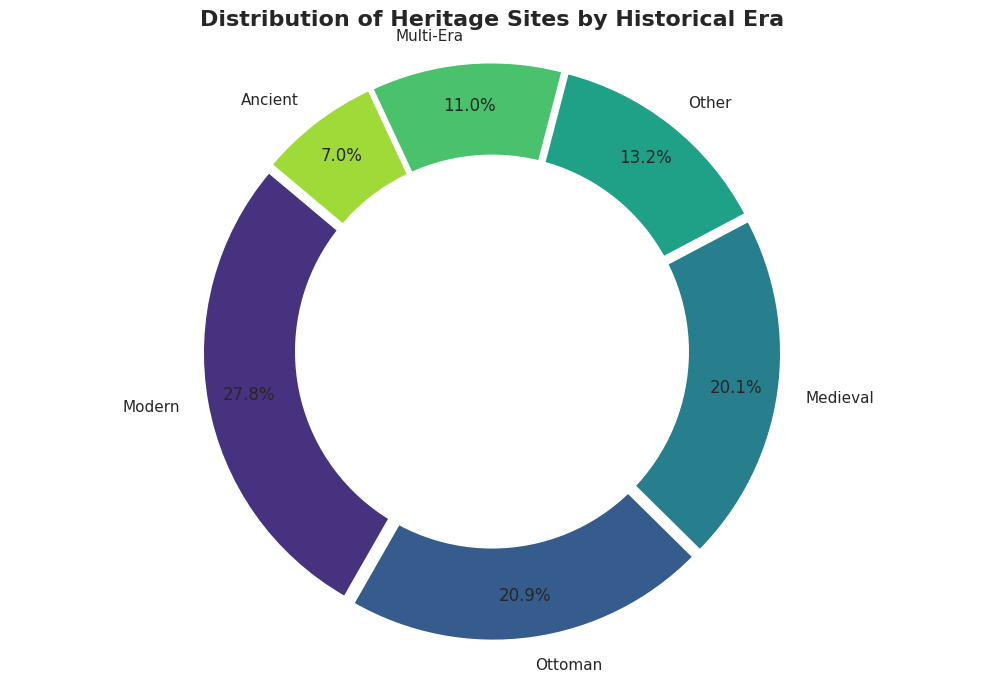

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for the Donut Chart using our new 'era_group'
era_counts = df_final['era_group'].value_counts()

# 2. Setup the Plot
plt.figure(figsize=(10, 7))
sns.set_theme(style="white")

# Create the donut chart
colors = sns.color_palette("viridis", len(era_counts))
plt.pie(era_counts, labels=era_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, pctdistance=0.85,
        explode=[0.03]*len(era_counts), wedgeprops={'edgecolor': 'white'})

# Add the center circle (The Donut hole)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Heritage Sites by Historical Era', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('era_distribution.png') # Saving for the report
plt.show()


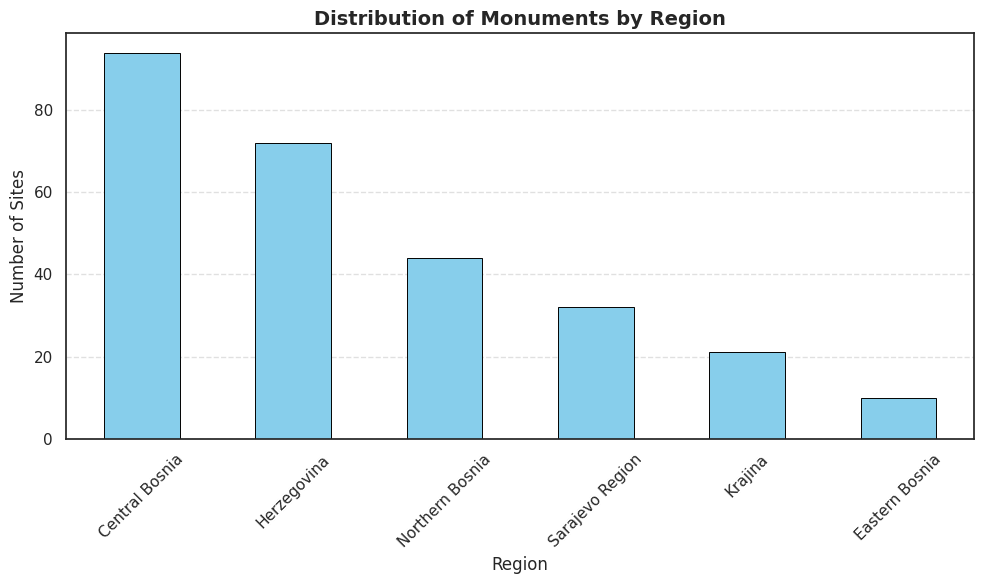

In [149]:
import matplotlib.pyplot as plt

# 1. Generate the Plot
plt.figure(figsize=(10, 6))
df_final['region'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', linewidth=0.7)

# 2. Add Professional Labels
plt.title('Distribution of Monuments by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Sites', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 3. Final Polish
plt.tight_layout()
plt.show()

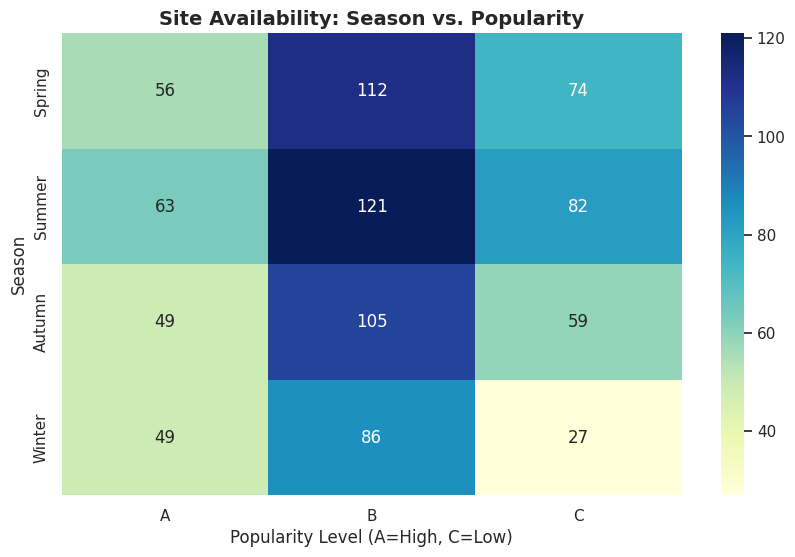

In [150]:
# --- STEP 1: PREPARE DATA FOR HEATMAP ---
# We use the 'is_...' columns we already created during preprocessing!
seasonal_cols = ['is_spring', 'is_summer', 'is_autumn', 'is_winter']
season_labels = ['Spring', 'Summer', 'Autumn', 'Winter']

# We group by popularity and sum our binary flags
heatmap_data = df_final.groupby('popularity_level')[seasonal_cols].sum().transpose()

# Rename index for a prettier plot
heatmap_data.index = season_labels

# --- STEP 2: PLOT ---
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar=True, fmt='g')

plt.title('Site Availability: Season vs. Popularity', fontsize=14, fontweight='bold')
plt.ylabel('Season')
plt.xlabel('Popularity Level (A=High, C=Low)')
plt.show()

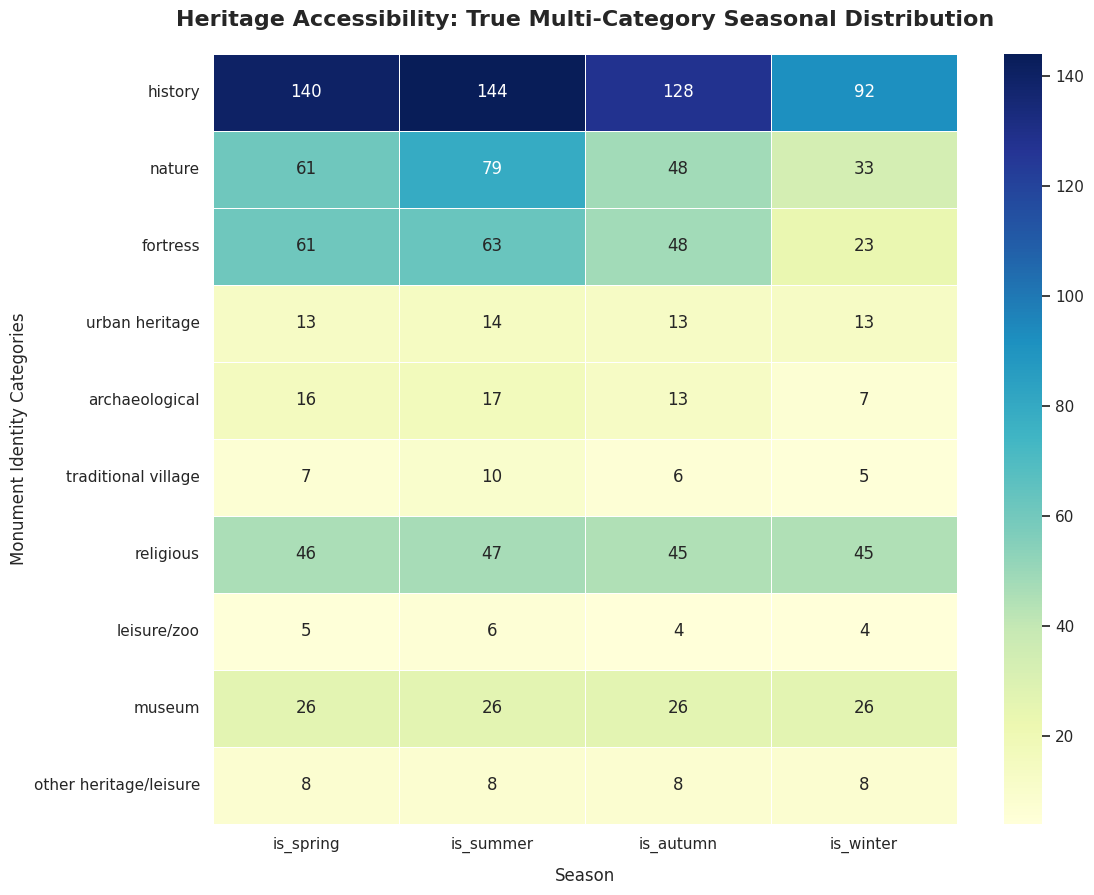

In [151]:
# Updated Master list containing 'history'
master_categories = ['history', 'nature', 'fortress', 'urban heritage', 'archaeological',
                     'traditional village', 'religious', 'leisure/zoo', 'museum', 'other heritage/leisure']
seasonal_cols = ['is_spring', 'is_summer', 'is_autumn', 'is_winter']

nested_heatmap_data = {}
for cat in master_categories:
    mask = df_final['multiverse_categories'].apply(lambda x: cat in x if isinstance(x, list) else False)
    nested_heatmap_data[cat] = df_final[mask][seasonal_cols].sum()

heatmap_data_final = pd.DataFrame(nested_heatmap_data).T

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_final, annot=True, fmt='g', cmap="YlGnBu", linewidths=0.5, linecolor='white')
plt.title('Heritage Accessibility: True Multi-Category Seasonal Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Season', fontsize=12, labelpad=10)
plt.ylabel('Monument Identity Categories', fontsize=12)
plt.xticks(rotation=0)
plt.show()

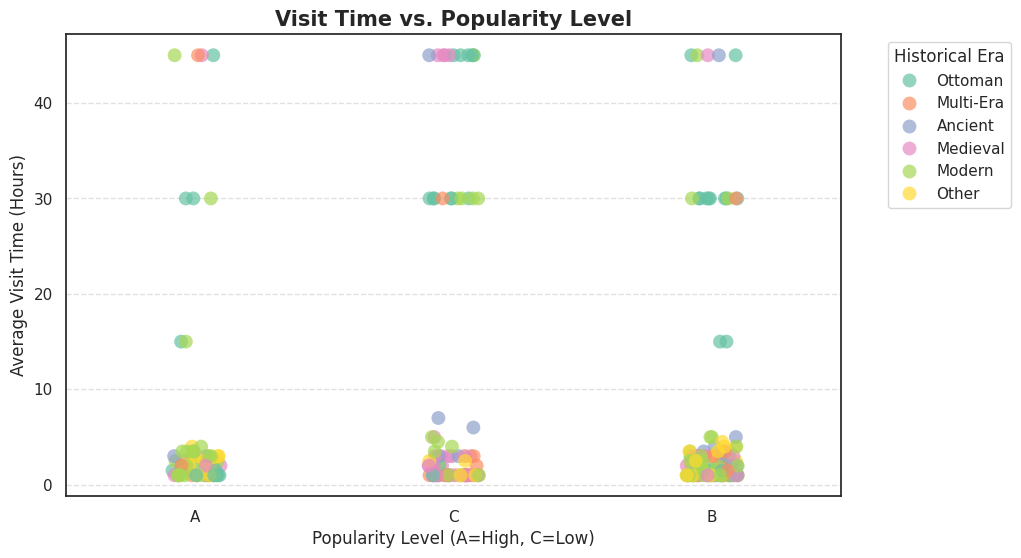

In [152]:
# Convert visit time to a numeric value for plotting (e.g., "2-3 hours" -> 2.5)
def convert_time(time_str):
    nums = [int(s) for s in re.findall(r'\d+', str(time_str))]
    return sum(nums) / len(nums) if nums else 1.0

df_final['visit_time_num'] = df_final['avg_visit_time'].apply(convert_time)

plt.figure(figsize=(10, 6))
sns.stripplot(data=df_final, x='popularity_level', y='visit_time_num',
              hue='era_group', palette='Set2', size=10, alpha=0.7)

plt.title('Visit Time vs. Popularity Level', fontsize=15, fontweight='bold')
plt.xlabel('Popularity Level (A=High, C=Low)')
plt.ylabel('Average Visit Time (Hours)')
plt.legend(title='Historical Era', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

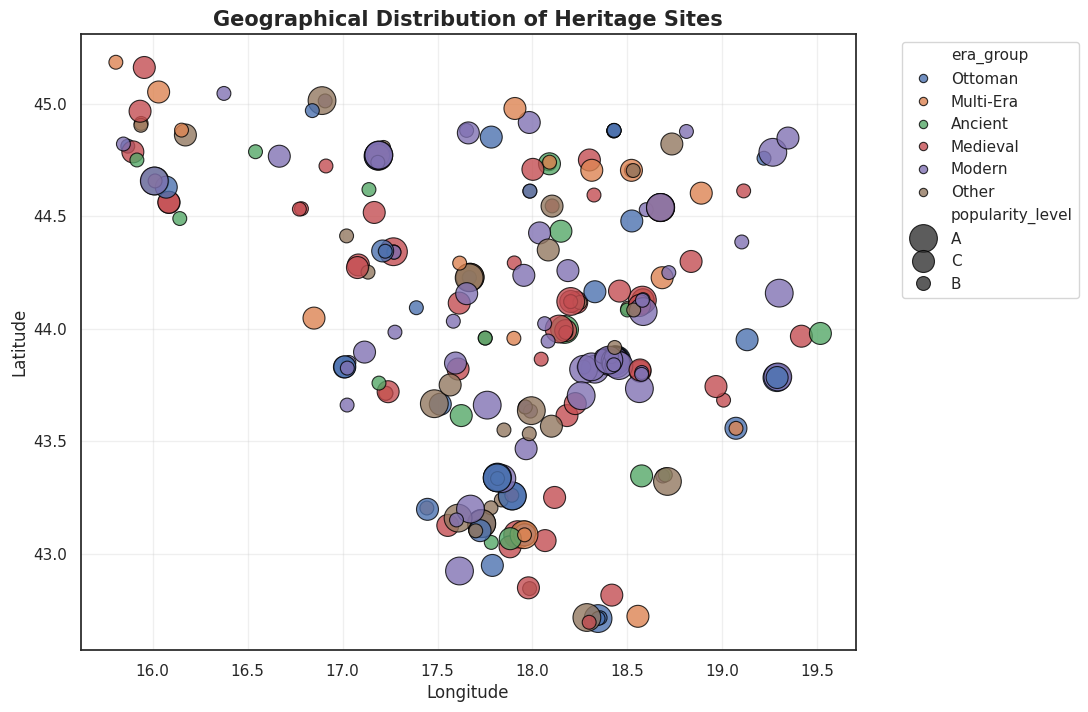

In [153]:
plt.figure(figsize=(10, 8))
# Use the era_group for color and popularity for size
sns.scatterplot(data=df_final, x='longitude', y='latitude',
                hue='era_group', size='popularity_level',
                sizes=(100, 400), palette='deep', alpha=0.8, edgecolors="black")

plt.title('Geographical Distribution of Heritage Sites', fontsize=15, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

#Phase 5: Vector Database (Retrieval Engine)

We use ChromaDB to handle the Semantic Search. This allows the chatbot to understand "vibes" and descriptions.

In [154]:
import chromadb
from chromadb.utils import embedding_functions

# 1. Initialize ChromaDB (Local Persist)
client = chromadb.PersistentClient(path="./heritage_db")

# 2. Use a standard, fast embedding model
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

# 3. Create (or get) the collection
collection = client.get_or_create_collection(name="bih_heritage", embedding_function=sentence_transformer_ef)

# 4. Prepare data for indexing
# We combine description and keywords for a richer search
documents = (df_final['description'] + " " + df_final['keywords']).tolist()
metadatas = df_final.to_dict(orient='records') # Stores the whole row as metadata
ids = df_final['name'].tolist()

# 5. Add to Vector Store
collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print(f" Vector Store Created! {len(ids)} sites indexed in './heritage_db'")

 Vector Store Created! 273 sites indexed in './heritage_db'


In [155]:
# Verify what's inside the 'brains' of our AI
peek = collection.peek(3)

print("AI's Internal ID:", peek['ids'])
print("---")
print("AI's Vector Representation (first 5 numbers):", peek['embeddings'][0][:5])

AI's Internal ID: ['Stari Most', 'Baščaršija', 'Kastel Fortress']
---
AI's Vector Representation (first 5 numbers): [ 0.03675912  0.09817224 -0.0431604  -0.02161815 -0.07300154]


In [156]:
# Check a single entry to see how the metadata looks inside the DB
sample = collection.peek(limit=1)
print("--- DATABASE METADATA CHECK ---")
print(sample['metadatas'][0])

# Verify if 'Nature/Leisure' or other slash-categories still exist
all_metas = collection.get()['metadatas']
categories_in_db = set([m['category'] for m in all_metas])
print(f"\nUnique Categories in DB: {categories_in_db}")

--- DATABASE METADATA CHECK ---
{'location': 'mostar', 'fun_fact': 'Local divers jump from the bridge into the cold Neretva river as a traditional rite of passage.', 'is_spring': 0, 'pop_num': 3, 'description': 'A 16th-century Ottoman bridge crossing the Neretva river, a symbol of the city and a UNESCO World Heritage site.', 'avg_visit_time': '1 hour', 'is_autumn': 0, 'source': 'https://en.wikipedia.org/wiki/Stari_Most', 'tourism_season': 'Summer', 'is_summer': 1, 'era_group': 'Ottoman', 'longitude': 17.815, 'category': 'monument', 'region': 'Herzegovina', 'is_winter': 0, 'multiverse_categories': ['monument', 'history'], 'visit_time_num': 1.0, 'historical_period': 'Ottoman', 'name': 'Stari Most', 'popularity_level': 'A', 'keywords': 'bridge, UNESCO, Ottoman, Neretva, architecture', 'latitude': 43.3373}

Unique Categories in DB: {'museum', 'fortress', 'nature', 'archaeological', 'urban heritage', 'other heritage/leisure', 'traditional village', 'religious', 'monument'}


In [157]:
import os
db_path = "/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db"

if not os.path.exists(db_path):
    os.makedirs(db_path)

import chromadb


client = chromadb.PersistentClient(path=db_path)
collection = client.get_or_create_collection(name="bih_heritage", embedding_function=sentence_transformer_ef)

In [158]:
# 1. Combine text for the AI to read
documents = (df_final['description'] + " " + df_final['keywords']).tolist()
metadatas = df_final.to_dict(orient='records')
ids = df_final['name'].tolist()

# 2. Add them to the collection
collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

# 3. FORCE a "Save" to Drive
import gc
client = None
gc.collect()

print(" Data pushed! Check your Drive folder in 10-20 seconds.")

 Data pushed! Check your Drive folder in 10-20 seconds.


In [159]:
client = chromadb.PersistentClient(path=db_path)
collection = client.get_collection(name="bih_heritage")
print(f"Total sites in Drive: {collection.count()}")

Total sites in Drive: 294


# Notebook 01 Summary: AI-Ready Heritage Engine

We have successfully built a Knowledge Base for Bosnian Cultural Heritage.

    Numerical Logic: All categorical data (Seasons, Eras) is vectorized for the Random Forest.

    Semantic Logic: Descriptions are indexed in ChromaDB for Natural Language Processing.

    Spatial Balance: The dataset covers all major regions of BiH, ensuring no geographical bias.

The project is now ready for Phase 2: User Simulation & Recommendation Logic.

In [160]:
import os
import pandas as pd
import chromadb

csv_path = "/content/drive/MyDrive/Y2S1/MLSTProject/BiH_Heritage_Final_Clean.csv"

# 1. Inspect CSV File Directly
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Total Rows in DataFrame: {len(df)}")

    # Check Stari Most
    stari_mask = df.astype(str).apply(lambda row: row.str.contains('Stari Most', case=False)).any(axis=1)
    print(f"Matches for 'Stari Most': {stari_mask.sum()}")
    if stari_mask.sum() > 0:
        print(df[stari_mask][['name', 'location', 'category']].head(2))

    # Check Ponijeri again with stripped strings
    ponijeri_mask = df.astype(str).apply(lambda row: row.str.contains('Ponijeri', case=False)).any(axis=1)
    print(f"Matches for 'Ponijeri': {ponijeri_mask.sum()}")
else:
    print(f"File not found at {csv_path}")

print("\n" + "="*40 + "\n")

# 2. Inspect ChromaDB Collections across possible paths
possible_db_paths = ["heritage_db", "/content/heritage_db", "/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db"]

for path in possible_db_paths:
    if os.path.exists(path):
        try:
            client = chromadb.PersistentClient(path=path)
            cols = client.list_collections()
            print(f"Path '{path}' exists. Collections found: {[c.name for c in cols]}")
            if "bih_heritage" in [c.name for c in cols]:
                col = client.get_collection("bih_heritage")
                print(f"  -> Total items in 'bih_heritage': {col.count()}")
        except Exception as e:
            print(f"Error accessing {path}: {e}")

Total Rows in DataFrame: 259
Matches for 'Stari Most': 3
                              name location  category
0                       Stari Most   mostar  monument
131  Old Bridge in Mostar (Museum)   mostar    museum
Matches for 'Ponijeri': 1


Path 'heritage_db' exists. Collections found: ['bih_heritage']
  -> Total items in 'bih_heritage': 273
Path '/content/heritage_db' exists. Collections found: ['bih_heritage']
  -> Total items in 'bih_heritage': 273
Path '/content/drive/MyDrive/Y2S1/MLSTProject/heritage_db' exists. Collections found: ['bih_heritage']
  -> Total items in 'bih_heritage': 294
